In [1]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

import openpyxl
import requests
from io import BytesIO

Получение xlsx файла

In [2]:
RAW_DATA_PATH = (
        'https://raw.githubusercontent.com/FriceXXX/DA2/main/data/have_fun.xlsx'
    )

In [3]:
print("Reading file...")
content = requests.get(RAW_DATA_PATH).content

raw_pd = pd.read_excel(
    BytesIO(content),
    sheet_name=None,
    engine='openpyxl'
)

print("Read successfully.")

Reading file...
Read successfully.


Начало обработки файла

In [4]:
dfs_copy = raw_pd.copy()

In [5]:
def print_dfs_eda(
        dfs: dict[str, pd.DataFrame],
        info: bool=True,
        head: bool=True,
    ) -> None:
    for sheet_name, df in dfs.items():
        print("-" * 75)
        print(f'SHEET NAME')
        print(sheet_name)

        if info:
            print()
            print('DF INFO')
            print(df.info())

        if head:
            print()
            print('DF HEAD')
            print(df.head())

        print('\n')

In [6]:
print_dfs_eda(dfs_copy)

---------------------------------------------------------------------------
SHEET NAME
Ëèñò1

DF INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125124 entries, 0 to 125123
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        123249 non-null  float64       
 1   relative_humidity_2m  125124 non-null  int64         
 2   precipitation         123877 non-null  float64       
 3   rain                  125124 non-null  float64       
 4   snowfall              125124 non-null  float64       
 5   weathercode           125124 non-null  int64         
 6   wind_speed_10m        123872 non-null  float64       
 7   surface_pressure      125124 non-null  float64       
 8   ds                    125124 non-null  datetime64[ns]
 9   city                  125124 non-null  object        
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 9.5+ M

# Исправляем листы

## Кодировка

In [7]:
def fix_encoding(text):
    if isinstance(text, str):
        try:
            return text.encode('latin1').decode('cp1251') # декодировка
        except:
            return text
    return text

def fix_df_encoding(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [
        fix_encoding(col) if isinstance(col, str) else col
        for col in df.columns
    ]

    object_cols = df.select_dtypes(include='object').columns

    for col in object_cols:
        df[col] = df[col].apply(
            lambda x: fix_encoding(x)
            if isinstance(x, str)
            else x
        )

    return df

## Пустые столбцы

In [8]:
COLS = [
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'rain',
    'snowfall',
    'weathercode',
    'wind_speed_10m',
    'surface_pressure',
    'ds',
    'city'
]

In [9]:
def fix_sheet(df):
    df = df.copy()

    df = df.loc[:, ~df.columns.str.contains(r'^Unnamed')]

    fake_cols = [col for col in df.columns if str(col) not in COLS]
    if fake_cols:
        df.drop(columns=fake_cols)

    for col in df.columns:
        if col in COLS[:-2]:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        if col == 'city':
           df[col] = df['city'].astype(str).str.strip()
        if col == 'ds':
           df['ds'] = pd.to_datetime(df['ds'], errors='coerce')

    df = df.dropna(subset=['ds', 'city'])
    df = df.drop_duplicates(subset=['city', 'ds'])
    df = df.sort_values(['city', 'ds'])
    df = df.reset_index(drop=True)


    return df

In [10]:
dfs = {
    name: df
    for name, df in dfs_copy.items()
    if len(df) > 0
}

dfs = {
    fix_encoding(name): fix_df_encoding(df)
    for name, df in dfs.items()
}

dfs = {
    name: fix_sheet(df)
    for name, df in dfs.items()
}
print_dfs_eda(dfs)

---------------------------------------------------------------------------
SHEET NAME
Лист1

DF INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122673 entries, 0 to 122672
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        120833 non-null  float64       
 1   relative_humidity_2m  122673 non-null  int64         
 2   precipitation         121447 non-null  float64       
 3   rain                  122673 non-null  float64       
 4   snowfall              122673 non-null  float64       
 5   weathercode           122673 non-null  int64         
 6   wind_speed_10m        121446 non-null  float64       
 7   surface_pressure      122673 non-null  float64       
 8   ds                    122673 non-null  datetime64[ns]
 9   city                  122673 non-null  object        
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 9.4+ M

In [11]:
df = pd.concat([dfn for name, dfn in dfs.items()], ignore_index=True) # Объединяем листы в один

df = df.sort_values(['city', 'ds']) # Сортим по городу и времени
df = df.reset_index(drop=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368092 entries, 0 to 368091
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        363803 non-null  float64       
 1   relative_humidity_2m  368087 non-null  float64       
 2   precipitation         364410 non-null  float64       
 3   rain                  368092 non-null  float64       
 4   snowfall              368092 non-null  float64       
 5   weathercode           366251 non-null  float64       
 6   wind_speed_10m        365028 non-null  float64       
 7   surface_pressure      368091 non-null  float64       
 8   ds                    368092 non-null  datetime64[ns]
 9   city                  368092 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 28.1+ MB


In [13]:
df['city'].value_counts()

,count
city,
Санкт-Петербург,61368
Сочи,61364
Москва,61363
Находка,61317
Геленджик,60420
Благовещенск,60414
Геленджикк,245
БЛАГОВЕЩЕНСК,242
Геленджи,233


Некоторые города были написаны с ошибками(опечатками)

In [14]:
city_names = {
    "Сочи": ["Счи", "Соч", "Сычи"],
    "Геленджик": ["ГЕЛЕНДЖИК", "геленджик", "Геленджи", "Геленджикк"],
    "Благовещенск": ["Благовещенс", "Благовещенскк", "благовещенск", "БЛАГОВЕЩЕНСК"],
    "Москва": ["Мосва"]
}

correct_names = {}

for right in city_names:
    for error in city_names[right]:
        correct_names[error] = right

df["city"] = df["city"].replace(correct_names)
df['city'] = df['city'].replace('nan', np.nan)
df = df.dropna(subset=['city'])


In [15]:
df = df.sort_values(['city', 'ds'])
df = df.reset_index(drop=True)
df['city'].value_counts()

,count
city,
Санкт-Петербург,61368
Сочи,61368
Москва,61364
Геленджик,61337
Благовещенск,61336
Находка,61317


Проверка на дубликаты информации

In [16]:
df.duplicated(['city', 'ds']).sum()

np.int64(0)

Проверка на пропуски во времени

In [17]:
df.groupby('city')['ds'].diff().value_counts()

,count
ds,
0 days 01:00:00,368017
0 days 02:00:00,65
0 days 03:00:00,1
1 days 07:00:00,1


Основной интервал между данными = 1 часу.
Существуют пропуски в 2-3 часа
существует пропуск длиной в 31 час

In [18]:
for city in df['city'].unique():

  city_df = df[df['city'] == city]
  print(city)
  print(city_df['ds'].diff().value_counts())


Благовещенск
ds
0 days 01:00:00    61303
0 days 02:00:00       32
Name: count, dtype: int64
Геленджик
ds
0 days 01:00:00    61305
0 days 02:00:00       31
Name: count, dtype: int64
Москва
ds
0 days 01:00:00    61360
0 days 02:00:00        2
0 days 03:00:00        1
Name: count, dtype: int64
Находка
ds
0 days 01:00:00    61315
1 days 07:00:00        1
Name: count, dtype: int64
Санкт-Петербург
ds
0 days 01:00:00    61367
Name: count, dtype: int64
Сочи
ds
0 days 01:00:00    61367
Name: count, dtype: int64


In [19]:
dfs = []

city_dfs = []

for city in df['city'].unique():

    city_df = df[df['city'] == city].copy()

    city_df = city_df.set_index('ds')

    full_range = pd.date_range(
        start=city_df.index.min(),
        end=city_df.index.max(),
        freq='h'
    )

    city_df = city_df.reindex(full_range)

    city_df['city'] = city

    city_df.index.name = 'ds'

    city_df = city_df.reset_index()

    dfs.append(city_df)

df = pd.concat(dfs, ignore_index=True)

In [20]:
df.groupby('city')['ds'].diff().value_counts()

,count
ds,
0 days 01:00:00,368181


пропуски заполнены с помощью NaN

## Убираем NaN

In [21]:
df = df.replace([np.inf, -np.inf], np.nan)
print((df['temperature_2m'] > 55).sum())
print((df['temperature_2m'] < -55).sum())

530
0


In [22]:
df.loc[df['temperature_2m'] > 55, 'temperature_2m'] = np.nan

In [23]:
df.isna().sum()

,0
ds,0
temperature_2m,4916
relative_humidity_2m,102
precipitation,3778
rain,97
snowfall,97
weathercode,1938
wind_speed_10m,3161
surface_pressure,97
city,0


In [24]:
COLS_FOR_INTERPOLATION = [
    "temperature_2m",
    "relative_humidity_2m",
    "surface_pressure",
    "wind_speed_10m"
]

city_dfs = []

for city in df['city'].unique():
    city_df = df[df['city'] == city].copy()

    city_df = city_df.set_index('ds')

    full_range = pd.date_range(
        start=city_df.index.min(),
        end=city_df.index.max(),
        freq='h'
    )

    city_df = city_df.reindex(full_range)

    for col in COLS_FOR_INTERPOLATION:
        if col in city_df.columns:
            city_df[col] = city_df[col].interpolate(
                method='linear',
                limit_direction='both'
            )

    if 'relative_humidity_2m' in city_df.columns:
        city_df['relative_humidity_2m'] = city_df['relative_humidity_2m'].clip(0, 100)

    city_df['city'] = city

    city_df.index.name = 'ds'
    city_df = city_df.reset_index()

    city_dfs.append(city_df)

df_int = pd.concat(city_dfs, ignore_index=True)
df_int.isna().sum()

df = df_int.copy()

Логично будет считать, что NaN в осадках это их отсутствие, т.к. иначе мы будем тыкать наугад, что плохо для нашей работы.

In [25]:
for city in df['city'].unique():
    city_mask = df['city'] == city
    for col in ['rain', 'snowfall']:
        if col in df.columns:
            df.loc[city_mask, col] = df.loc[city_mask, col].fillna(0)
    if 'precipitation' in df.columns:
        df.loc[city_mask, 'precipitation'] = df.loc[city_mask, 'precipitation'].fillna(0)

    if 'weathercode' in df.columns:
        city_data = df.loc[city_mask, 'weathercode']

        df.loc[city_mask, 'weathercode'] = city_data.interpolate(
            method='nearest',
            limit_direction='both',
            limit=24 # интерполяция с лимитом в 24 часа
        )

        df.loc[city_mask, 'weathercode'] = df.loc[city_mask, 'weathercode'].ffill()

        df.loc[city_mask, 'weathercode'] = df.loc[city_mask, 'weathercode'].bfill()

        if df.loc[city_mask, 'weathercode'].isna().any():
            most_common = df.loc[city_mask, 'weathercode'].mode()
            if not most_common.empty:
                df.loc[city_mask, 'weathercode'] = df.loc[city_mask, 'weathercode'].fillna(most_common[0])
            else:
                df.loc[city_mask, 'weathercode'] = df.loc[city_mask, 'weathercode'].fillna(0)

df.isna().sum()

,0
ds,0
temperature_2m,0
relative_humidity_2m,0
precipitation,0
rain,0
snowfall,0
weathercode,0
wind_speed_10m,0
surface_pressure,0
city,0


Все NaN убраны :)

# Посмотрим на выбросы

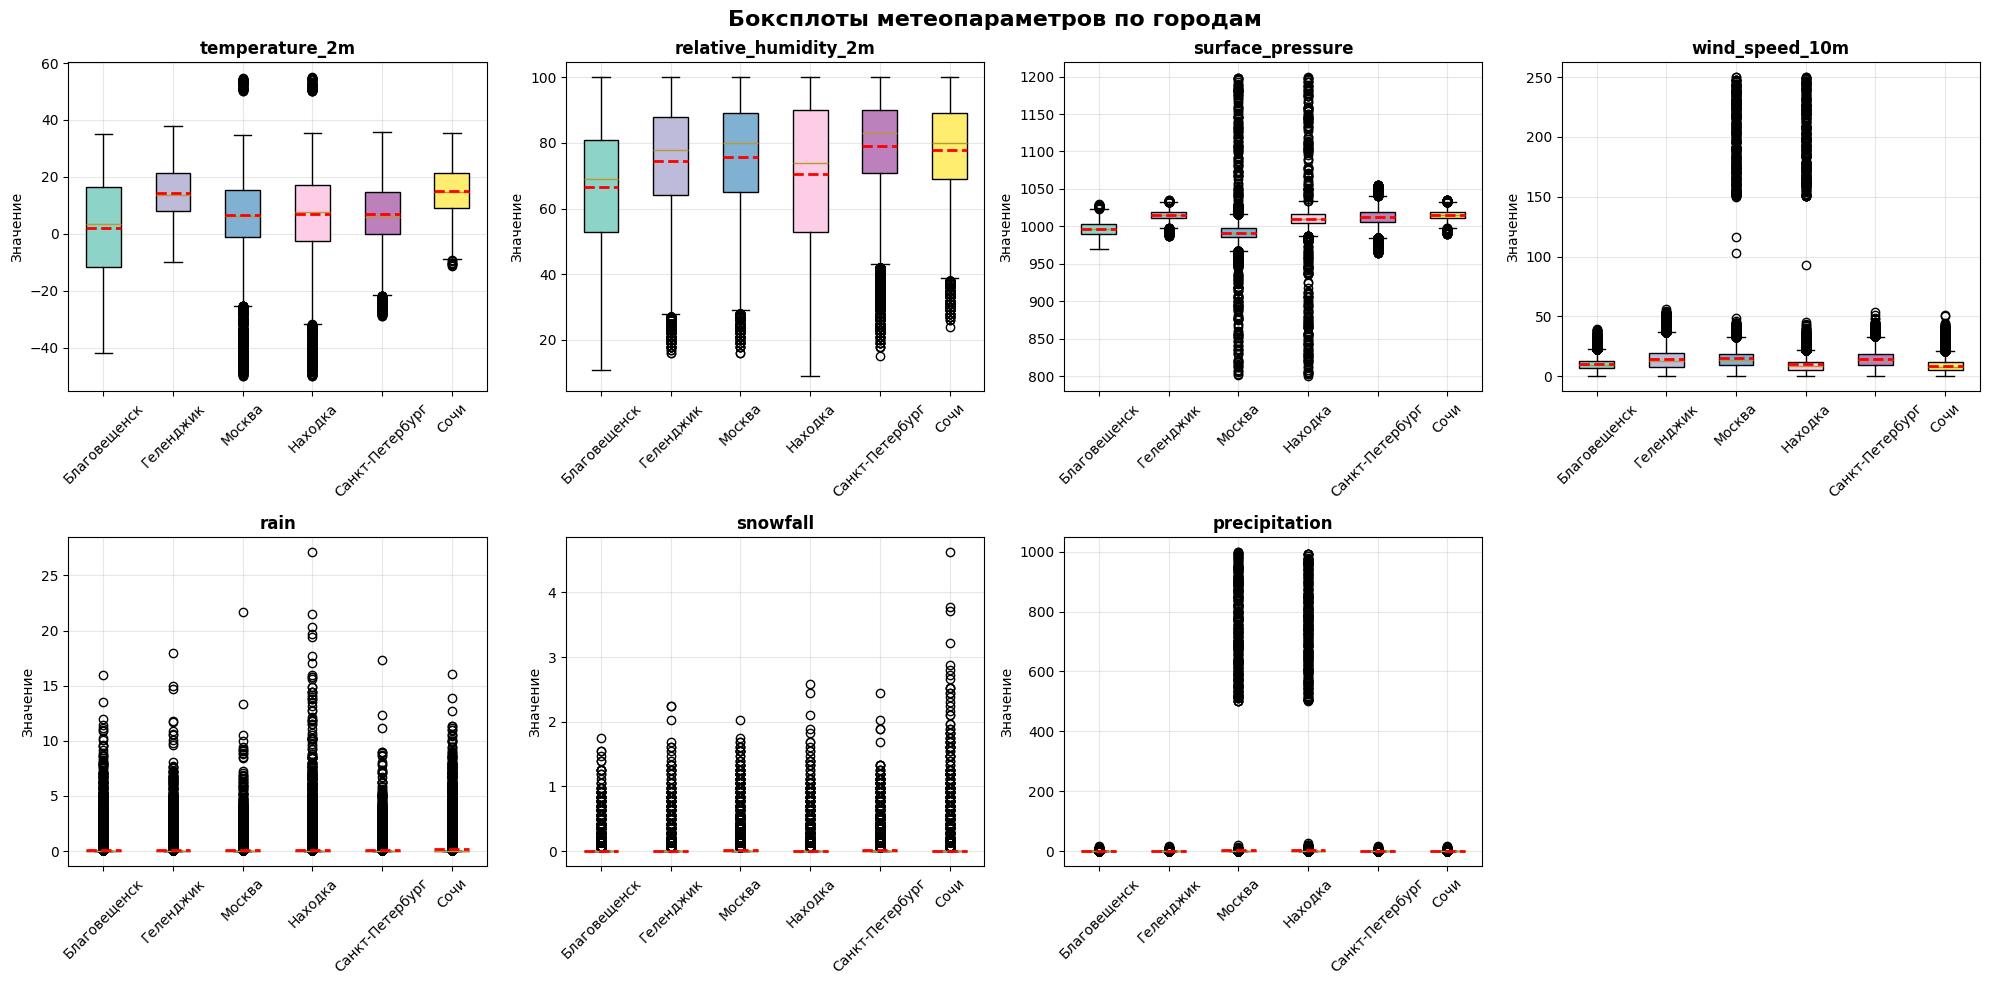

In [26]:
plt.style.use('default')
sns.set_palette("husl")

NUMERIC_COLS = [
    "temperature_2m",
    "relative_humidity_2m",
    "surface_pressure",
    "wind_speed_10m",
    "rain",
    "snowfall",
    "precipitation"
]

cities = df['city'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(cities)))
city_colors = dict(zip(cities, colors))

n_cols = 4
n_rows = (len(NUMERIC_COLS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))

if n_rows == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(NUMERIC_COLS):
    row = idx // n_cols
    col_idx = idx % n_cols

    data_to_plot = []
    city_labels = []
    for city in cities:
        city_data = df[df['city'] == city][col].dropna()
        if len(city_data) > 0:
            data_to_plot.append(city_data)
            city_labels.append(city)

    if data_to_plot:
        bp = axes[row, col_idx].boxplot(data_to_plot,
                                        tick_labels=city_labels,
                                        patch_artist=True,
                                        showmeans=True,
                                        meanline=True,
                                        meanprops=dict(color='red', linewidth=2))

        for patch, color in zip(bp['boxes'], colors[:len(data_to_plot)]):
            patch.set_facecolor(color)

        axes[row, col_idx].set_title(f'{col}', fontsize=12, fontweight='bold')
        axes[row, col_idx].set_ylabel('Значение')
        axes[row, col_idx].tick_params(axis='x', rotation=45)
        axes[row, col_idx].grid(True, alpha=0.3)

for idx in range(len(NUMERIC_COLS), n_rows * n_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    fig.delaxes(axes[row, col_idx])

plt.suptitle('Боксплоты метеопараметров по городам', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


Благовещенск


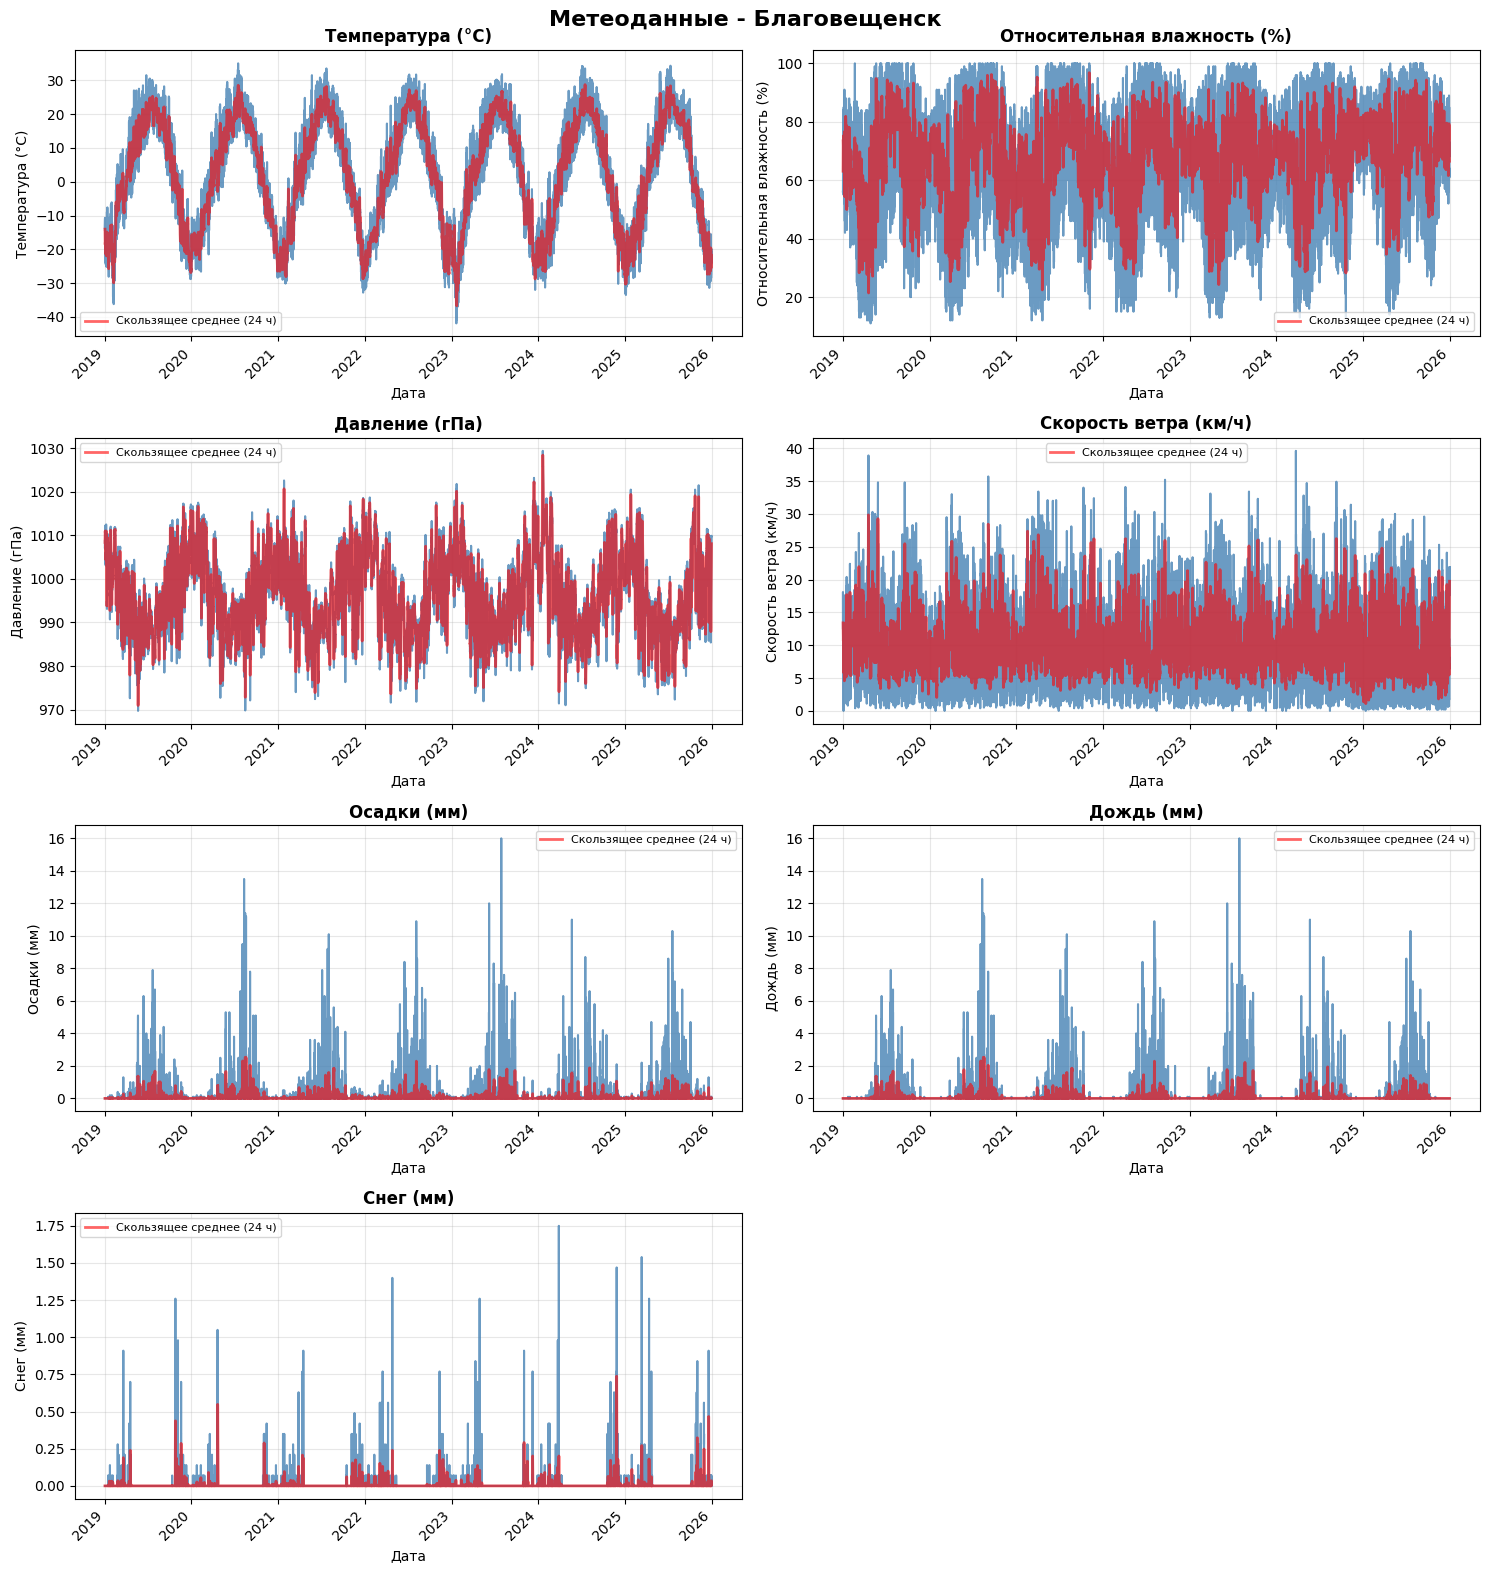


Геленджик


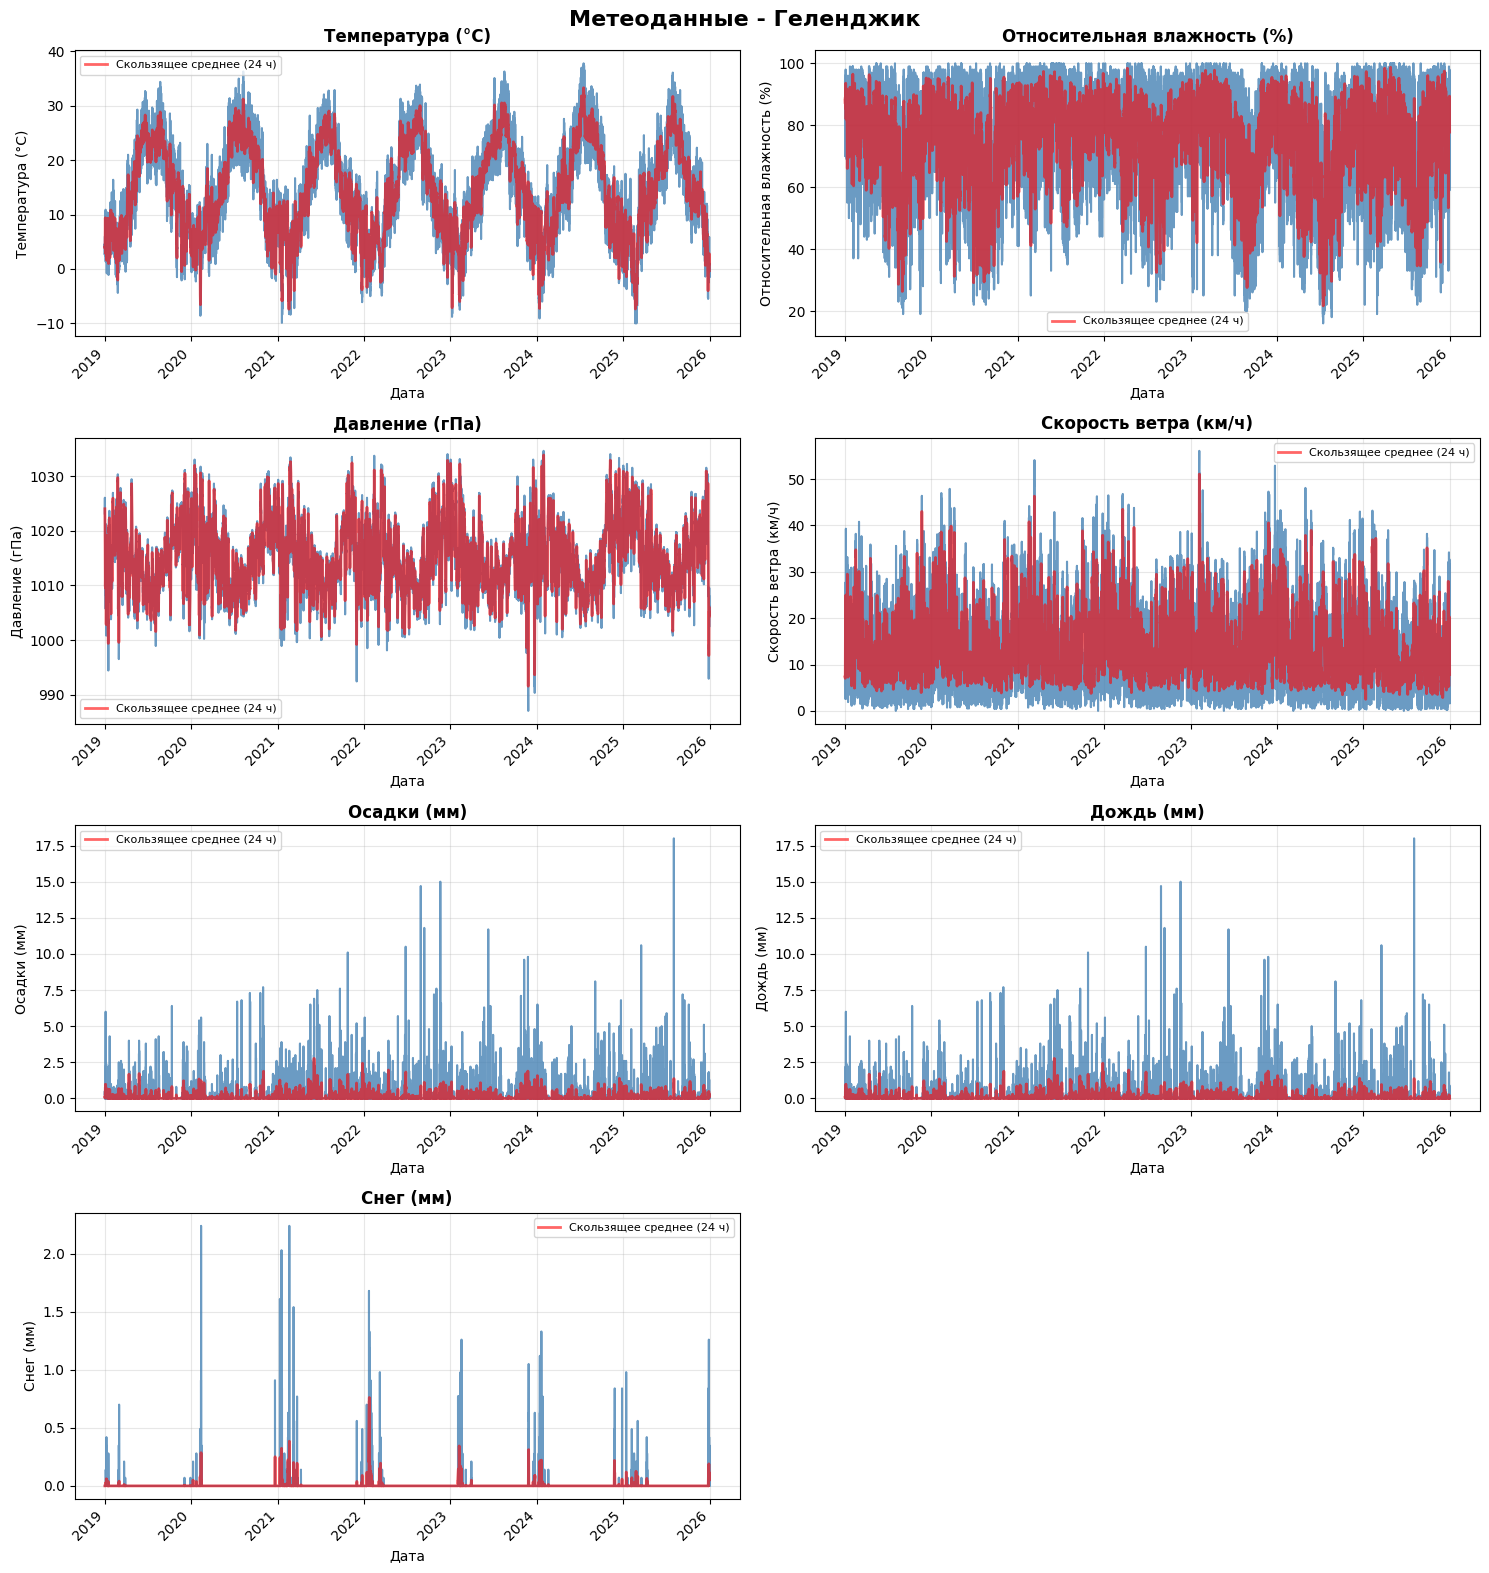


Москва


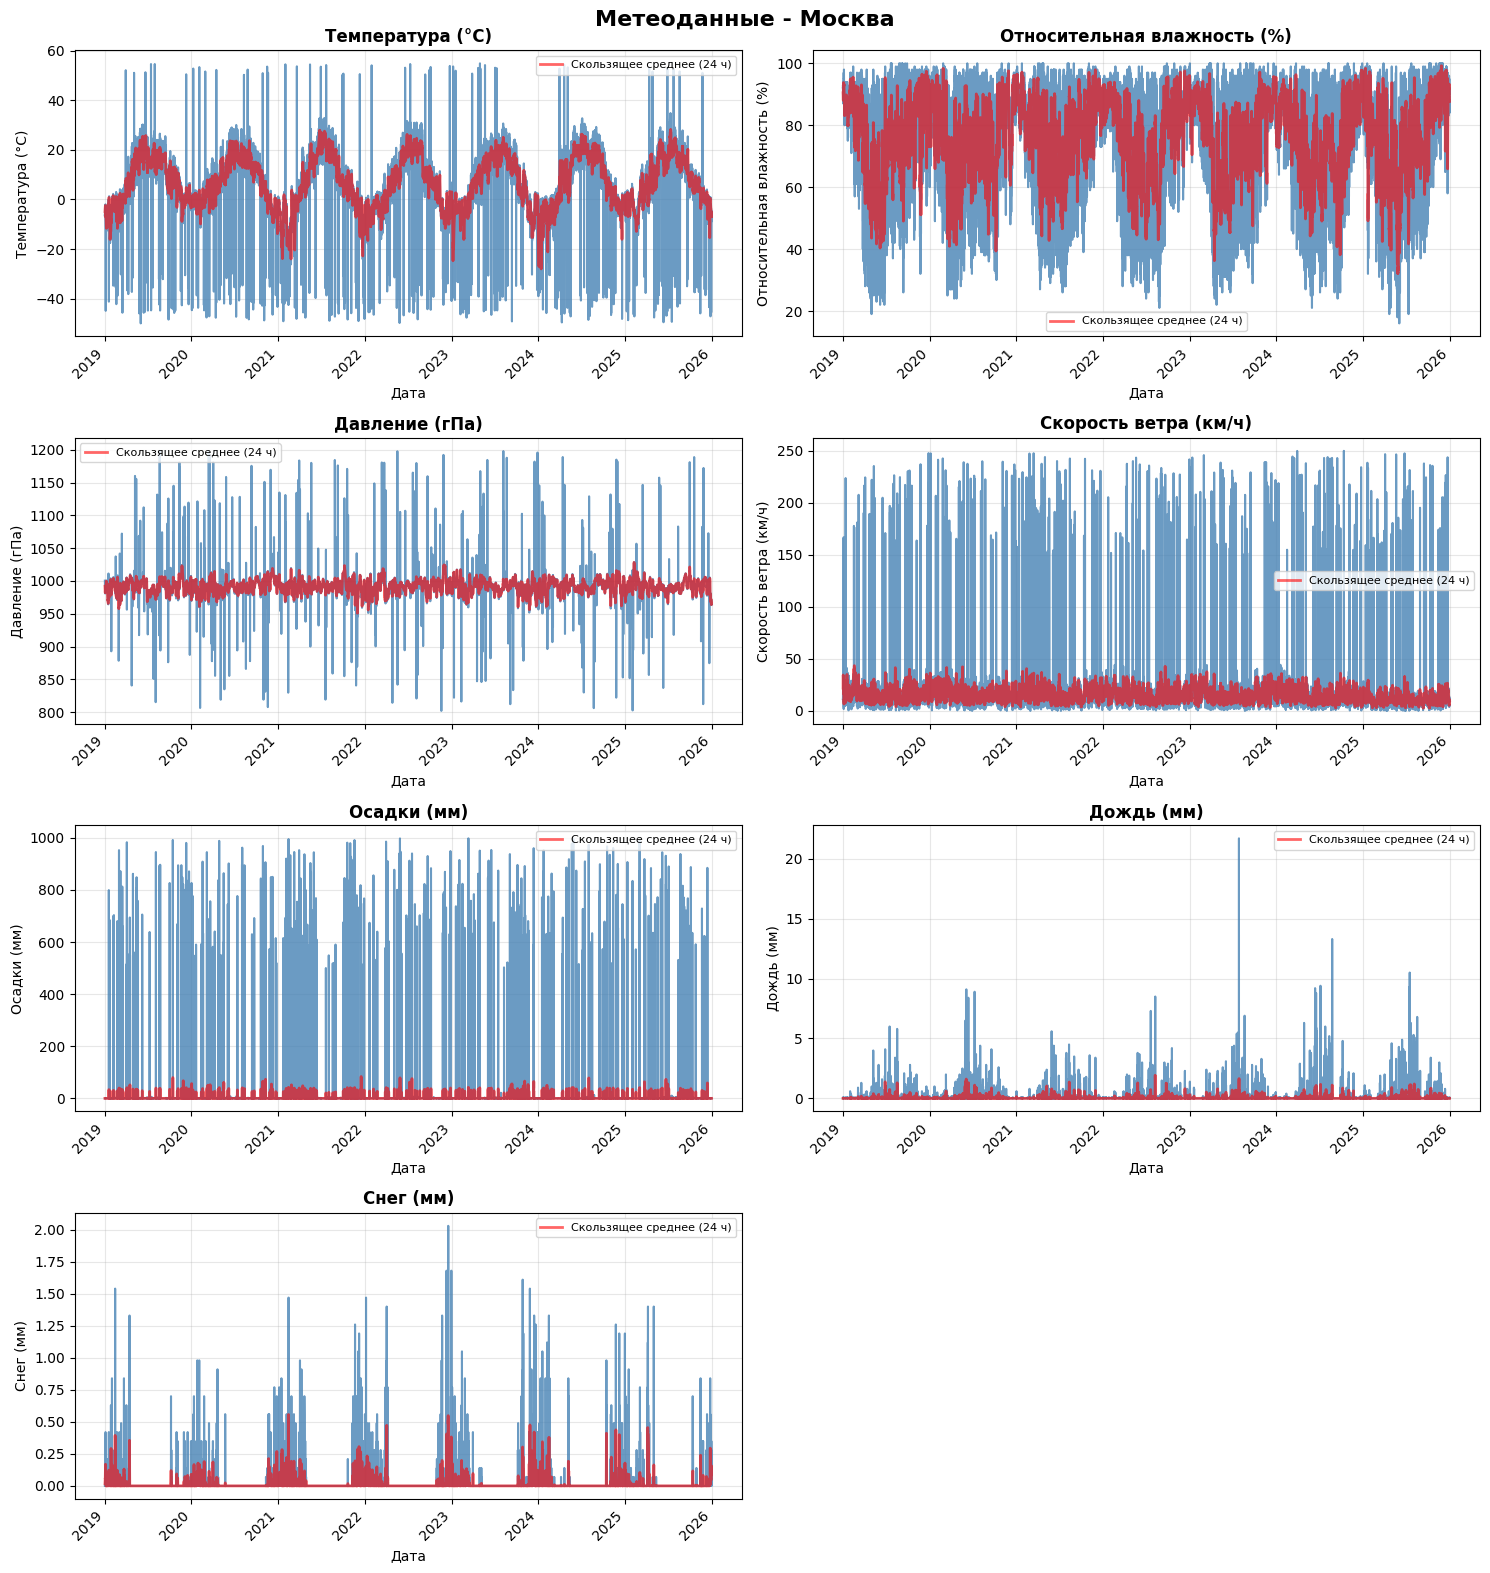


Находка


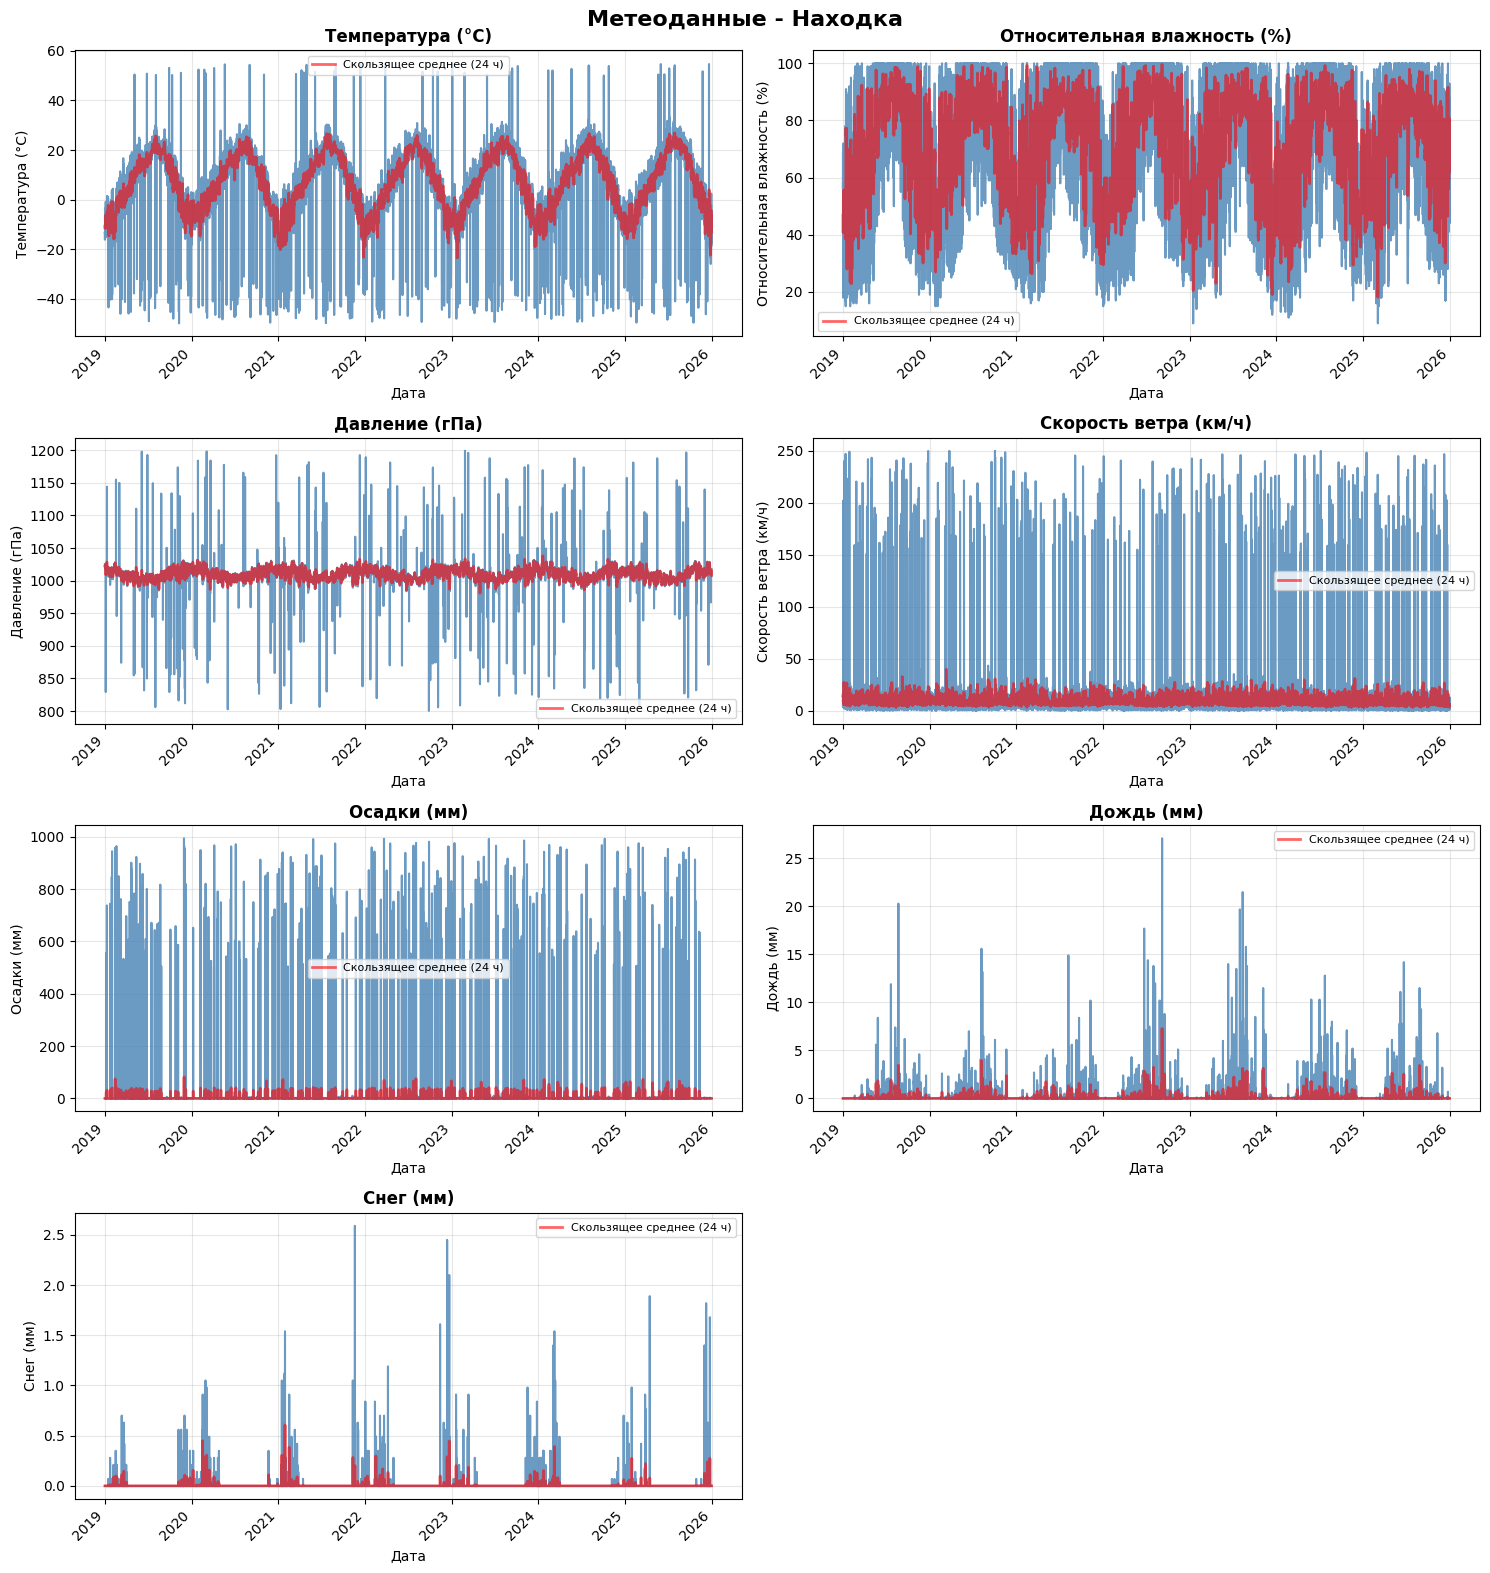


Санкт-Петербург


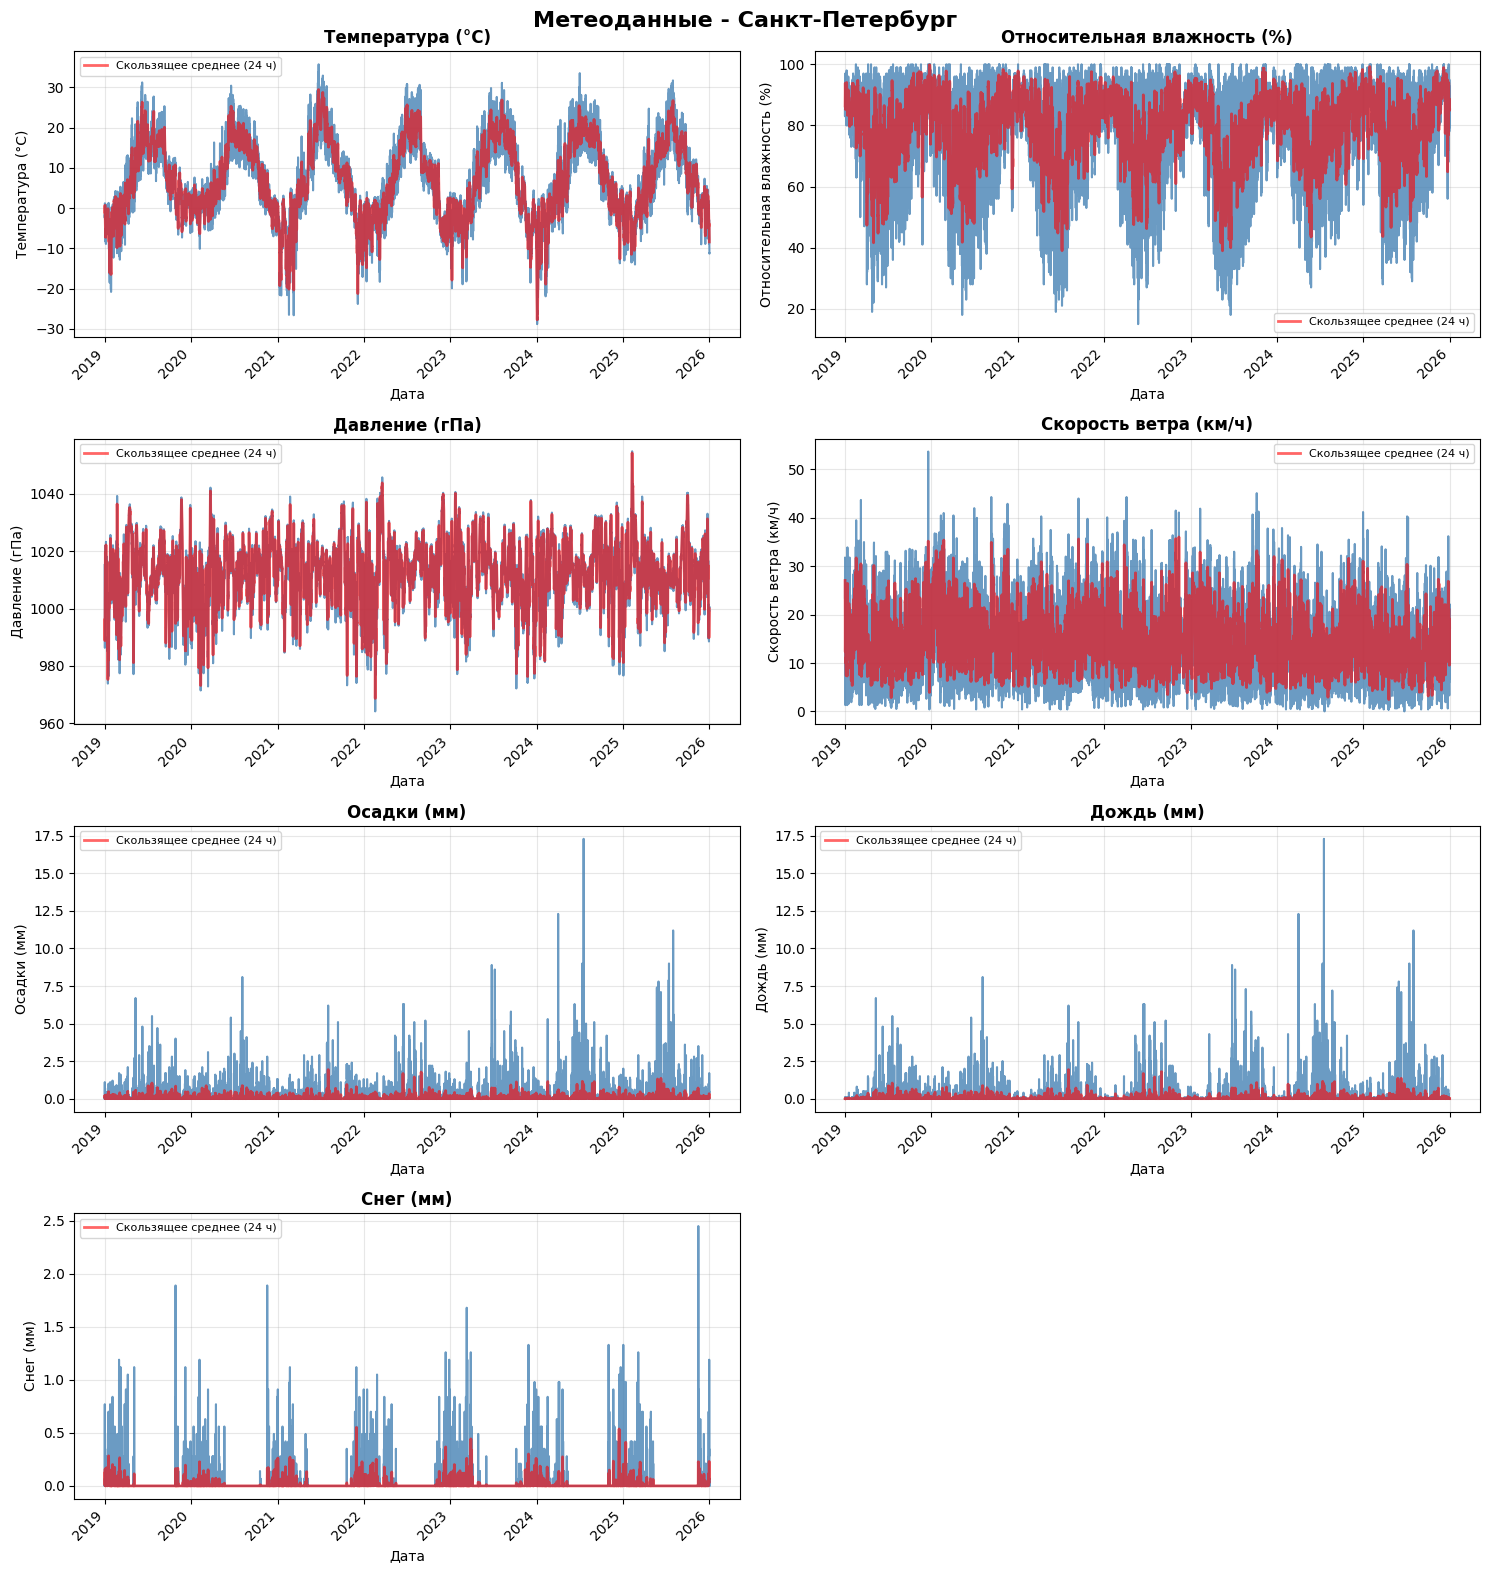


Сочи


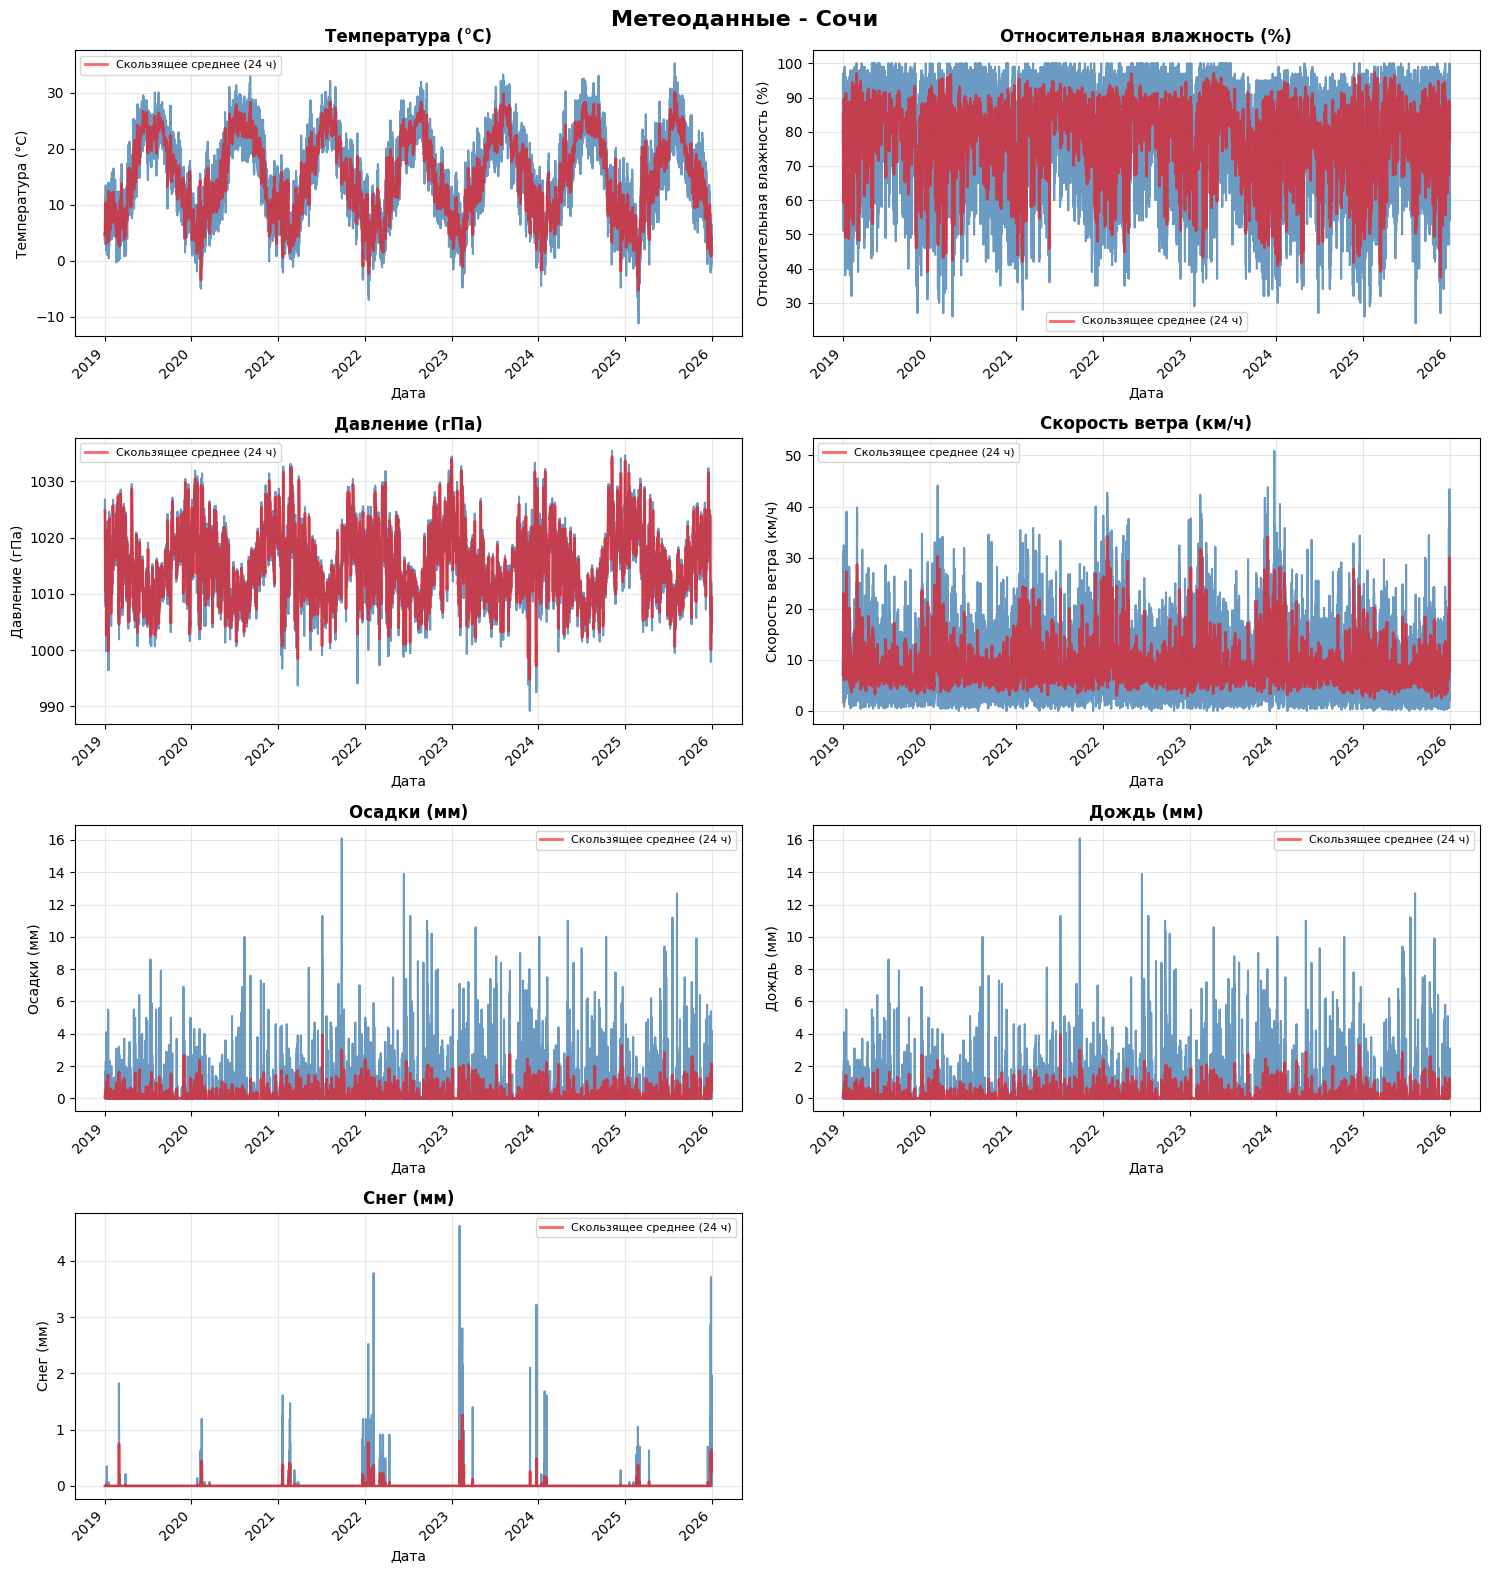

In [27]:
NUMERIC_COLS = [
    "temperature_2m",
    "relative_humidity_2m",
    "surface_pressure",
    "wind_speed_10m",
    "precipitation",
    "rain",
    "snowfall"
]

rus_names = {
    "temperature_2m": "Температура (°C)",
    "relative_humidity_2m": "Относительная влажность (%)",
    "surface_pressure": "Давление (гПа)",
    "wind_speed_10m": "Скорость ветра (км/ч)",
    "precipitation": "Осадки (мм)",
    "rain": "Дождь (мм)",
    "snowfall": "Снег (мм)"
}

cities = df['city'].unique()

for city in cities:
    print(f"\n{city}")

    city_data = df[df['city'] == city].sort_values('ds')

    n_params = len(NUMERIC_COLS)
    n_cols = 2
    n_rows = (n_params + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    fig.suptitle(f'Метеоданные - {city}', fontsize=16, fontweight='bold')

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for idx, col in enumerate(NUMERIC_COLS):
        row = idx // n_cols
        col_idx = idx % n_cols

        ax = axes[row, col_idx]

        ax.plot(city_data['ds'], city_data[col],
               linewidth=1.5, alpha=0.8, color='steelblue')

        window = 24
        if len(city_data) > window:
            rolling_mean = city_data[col].rolling(window=window, center=True).mean()
            ax.plot(city_data['ds'], rolling_mean,
                   linewidth=2, color='red', alpha=0.6,
                   label=f'Скользящее среднее ({window} ч)')

        ax.set_title(rus_names.get(col, col), fontsize=12, fontweight='bold')
        ax.set_xlabel('Дата')
        ax.set_ylabel(rus_names.get(col, col))
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)

        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    for idx in range(len(NUMERIC_COLS), n_rows * n_cols):
        row = idx // n_cols
        col_idx = idx % n_cols
        fig.delaxes(axes[row, col_idx])

    plt.tight_layout()
    plt.show()


Уберем аномальные скачки

In [28]:
cities = df['city'].unique()
for city in cities:
    city_mask = df['city'] == city
    for col in NUMERIC_COLS:
        rolling_median = (
            df.loc[city_mask, col].rolling(window=24, center=True,).median()
        )

        diff = np.abs(df.loc[city_mask, col] - rolling_median)

        threshold = diff.median() * 6

        outliers = (diff > threshold)
        df.loc[
            df.loc[city_mask].index[outliers],
            col
        ] = rolling_median[outliers]


Благовещенск


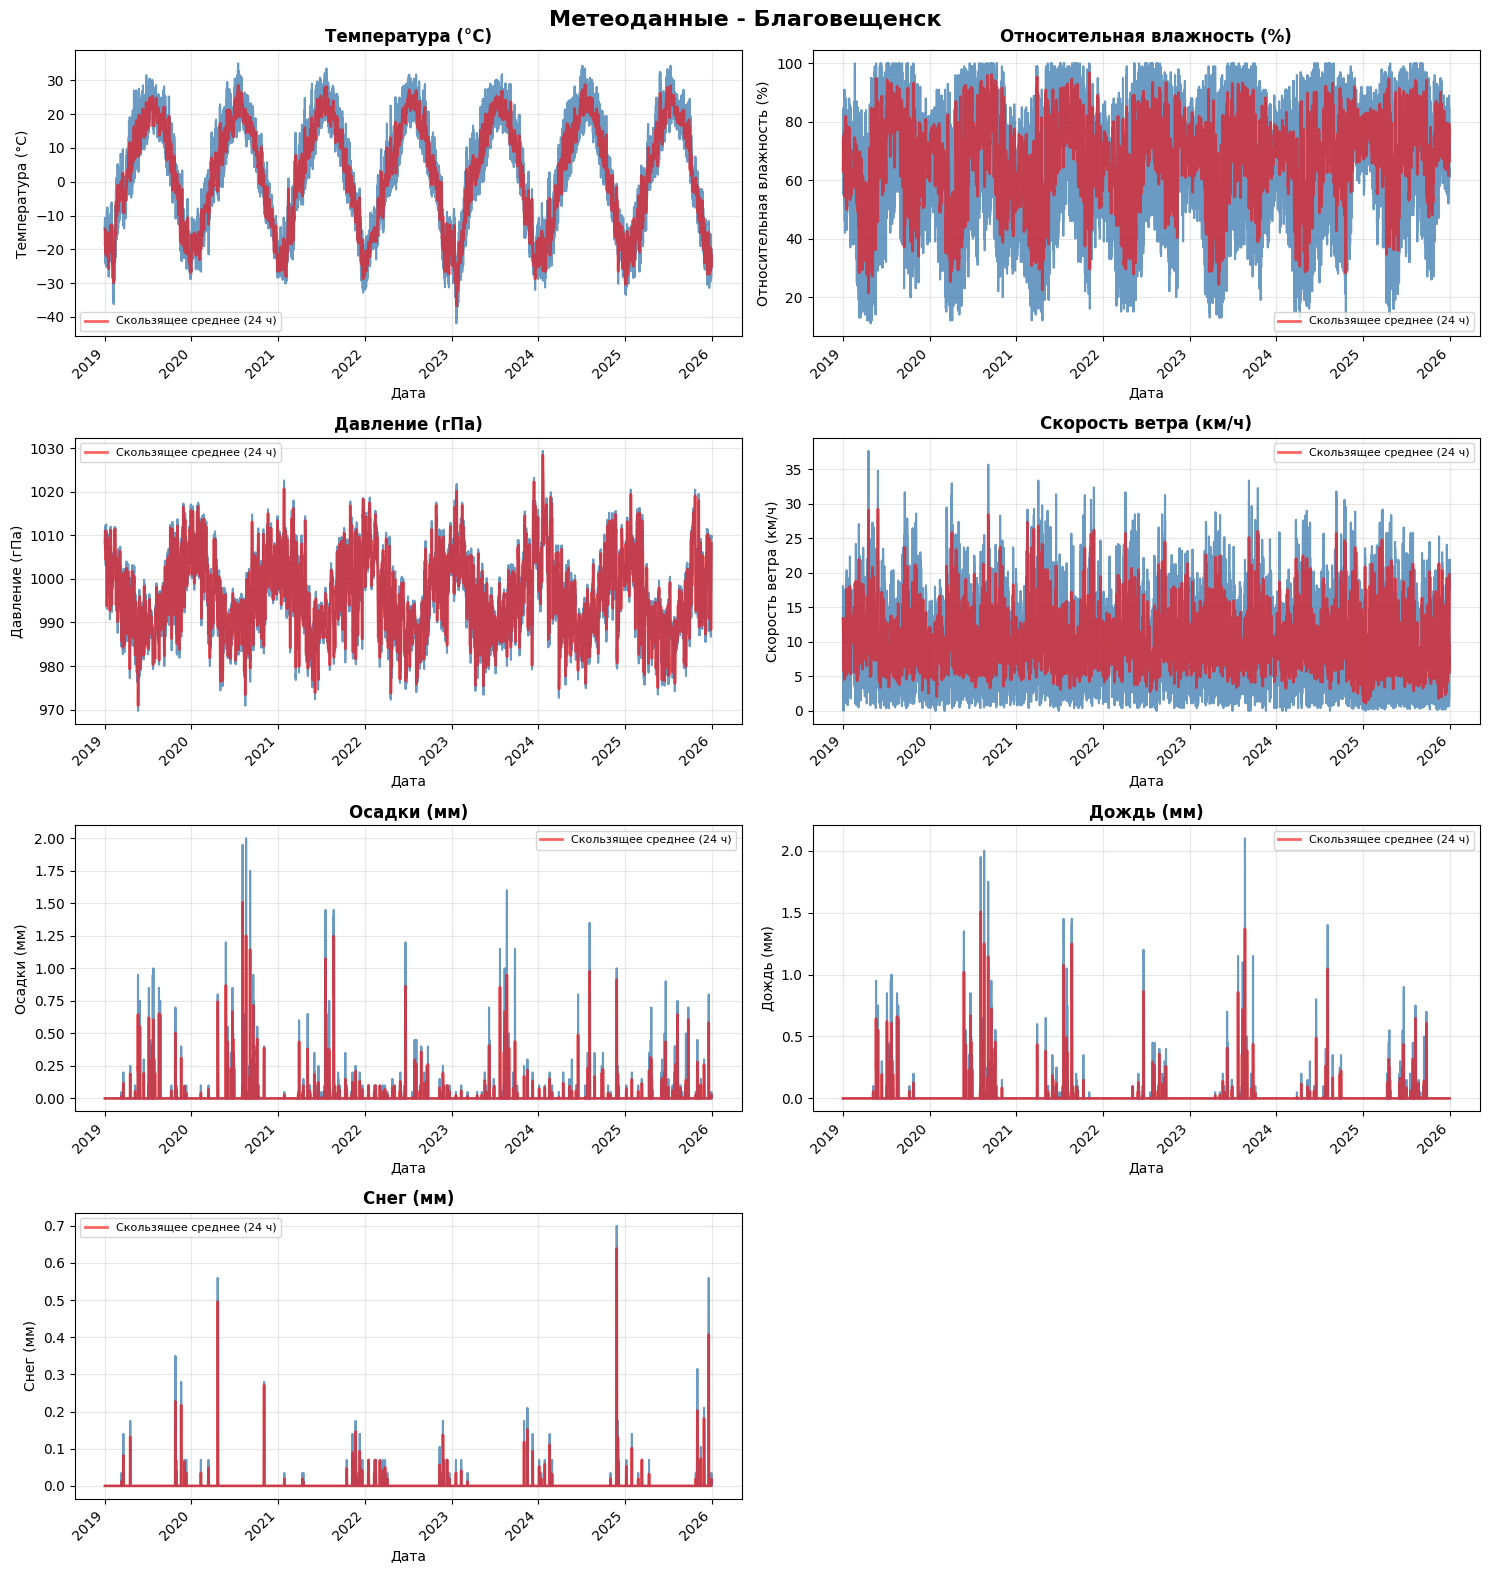


Геленджик


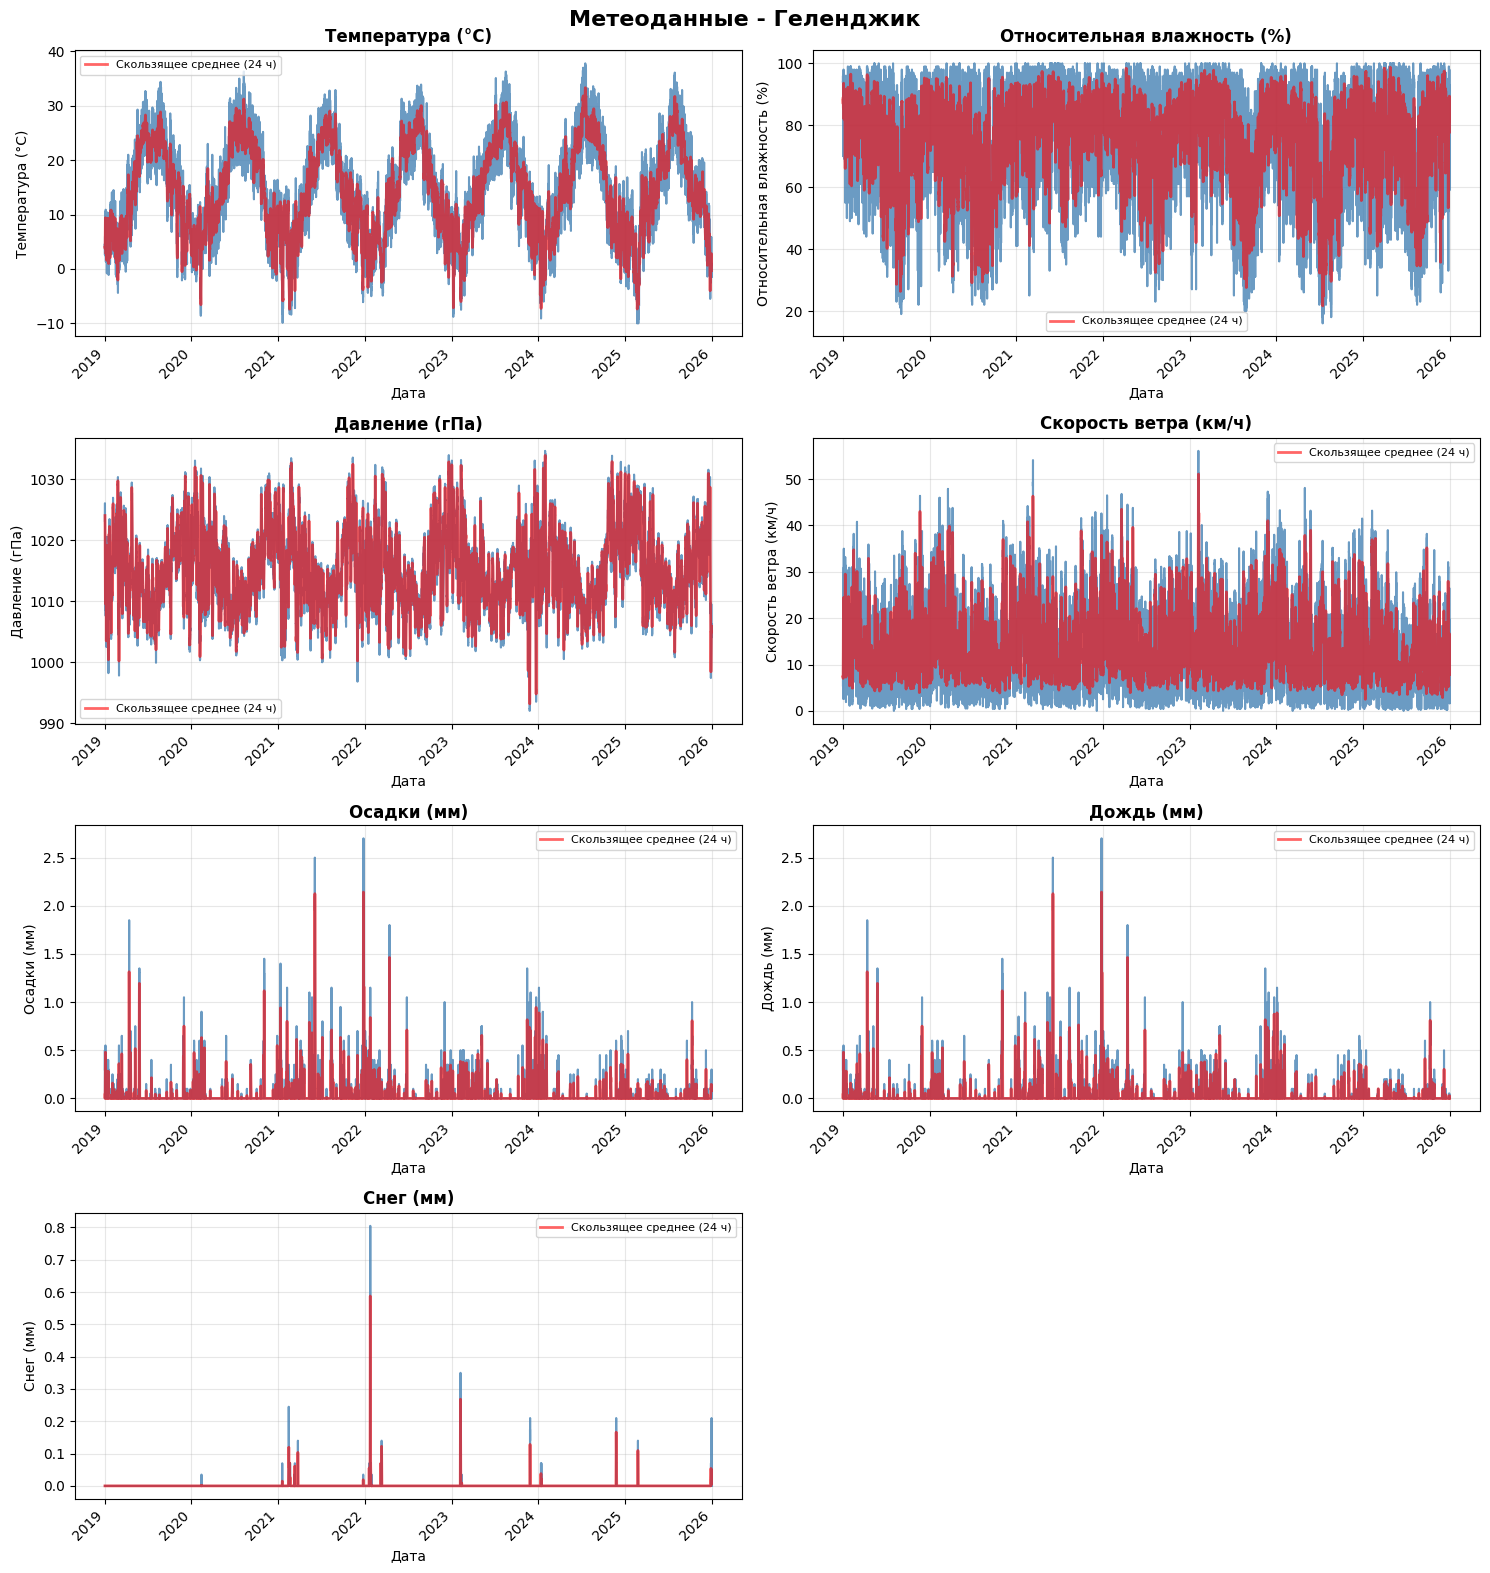


Москва


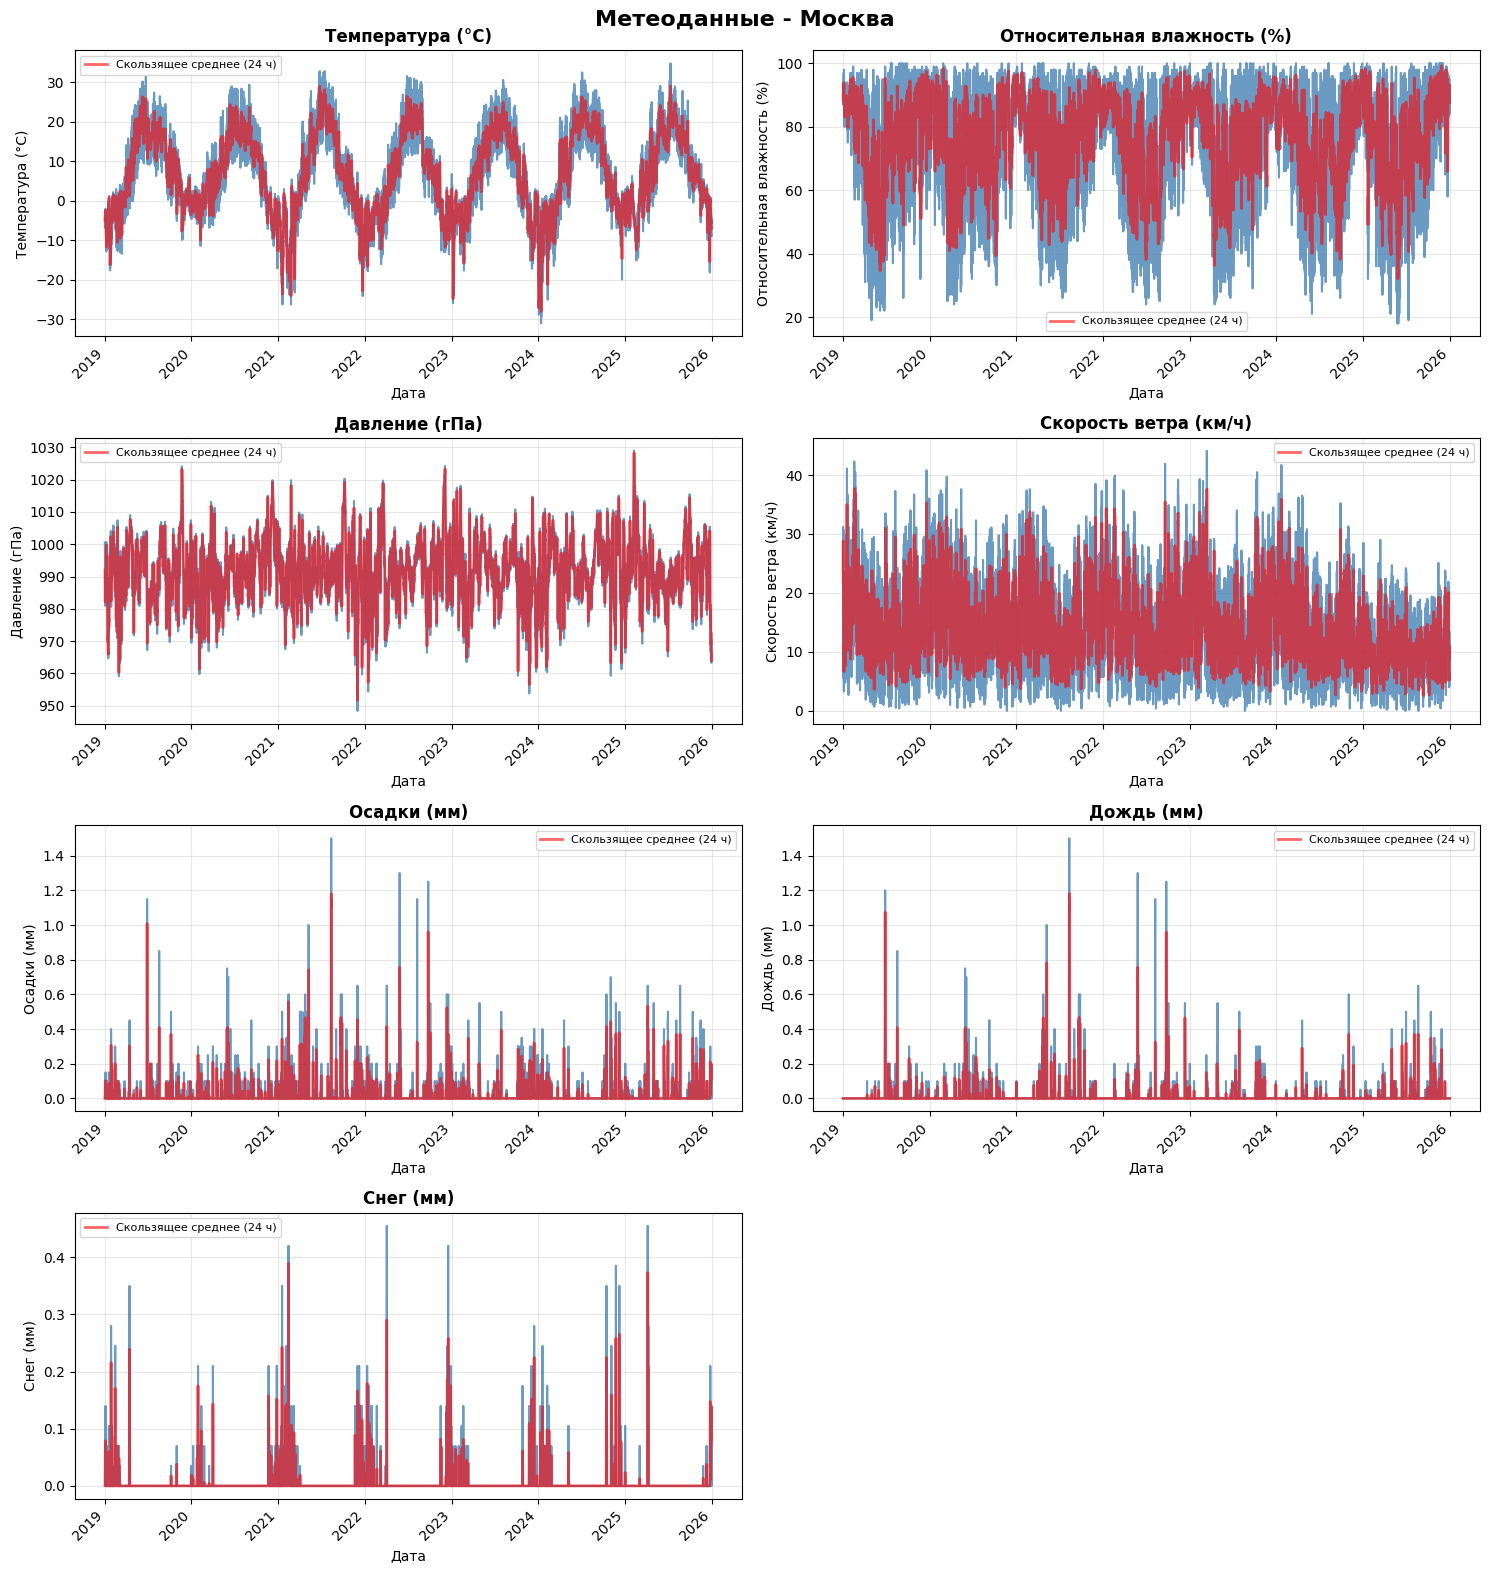


Находка


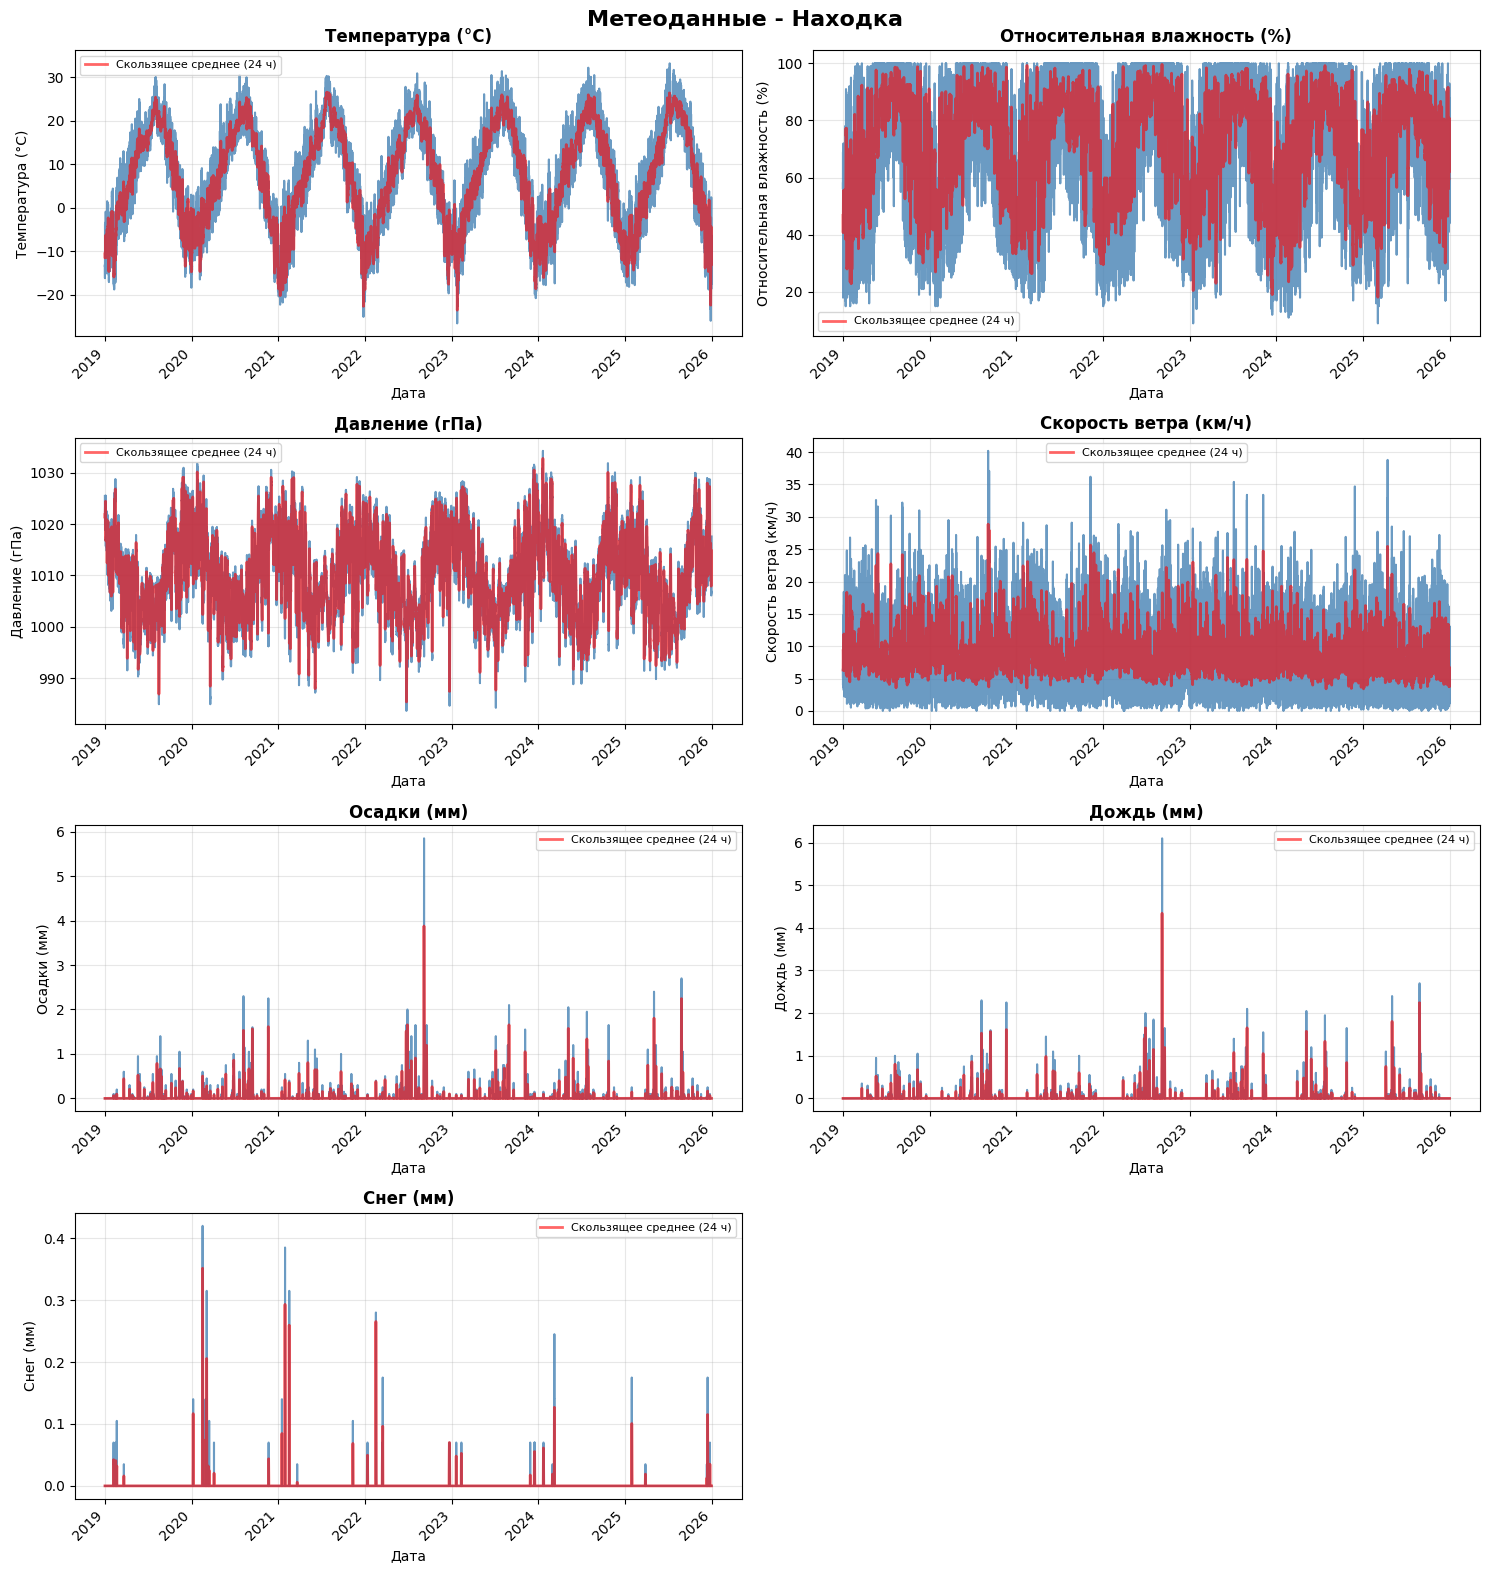


Санкт-Петербург


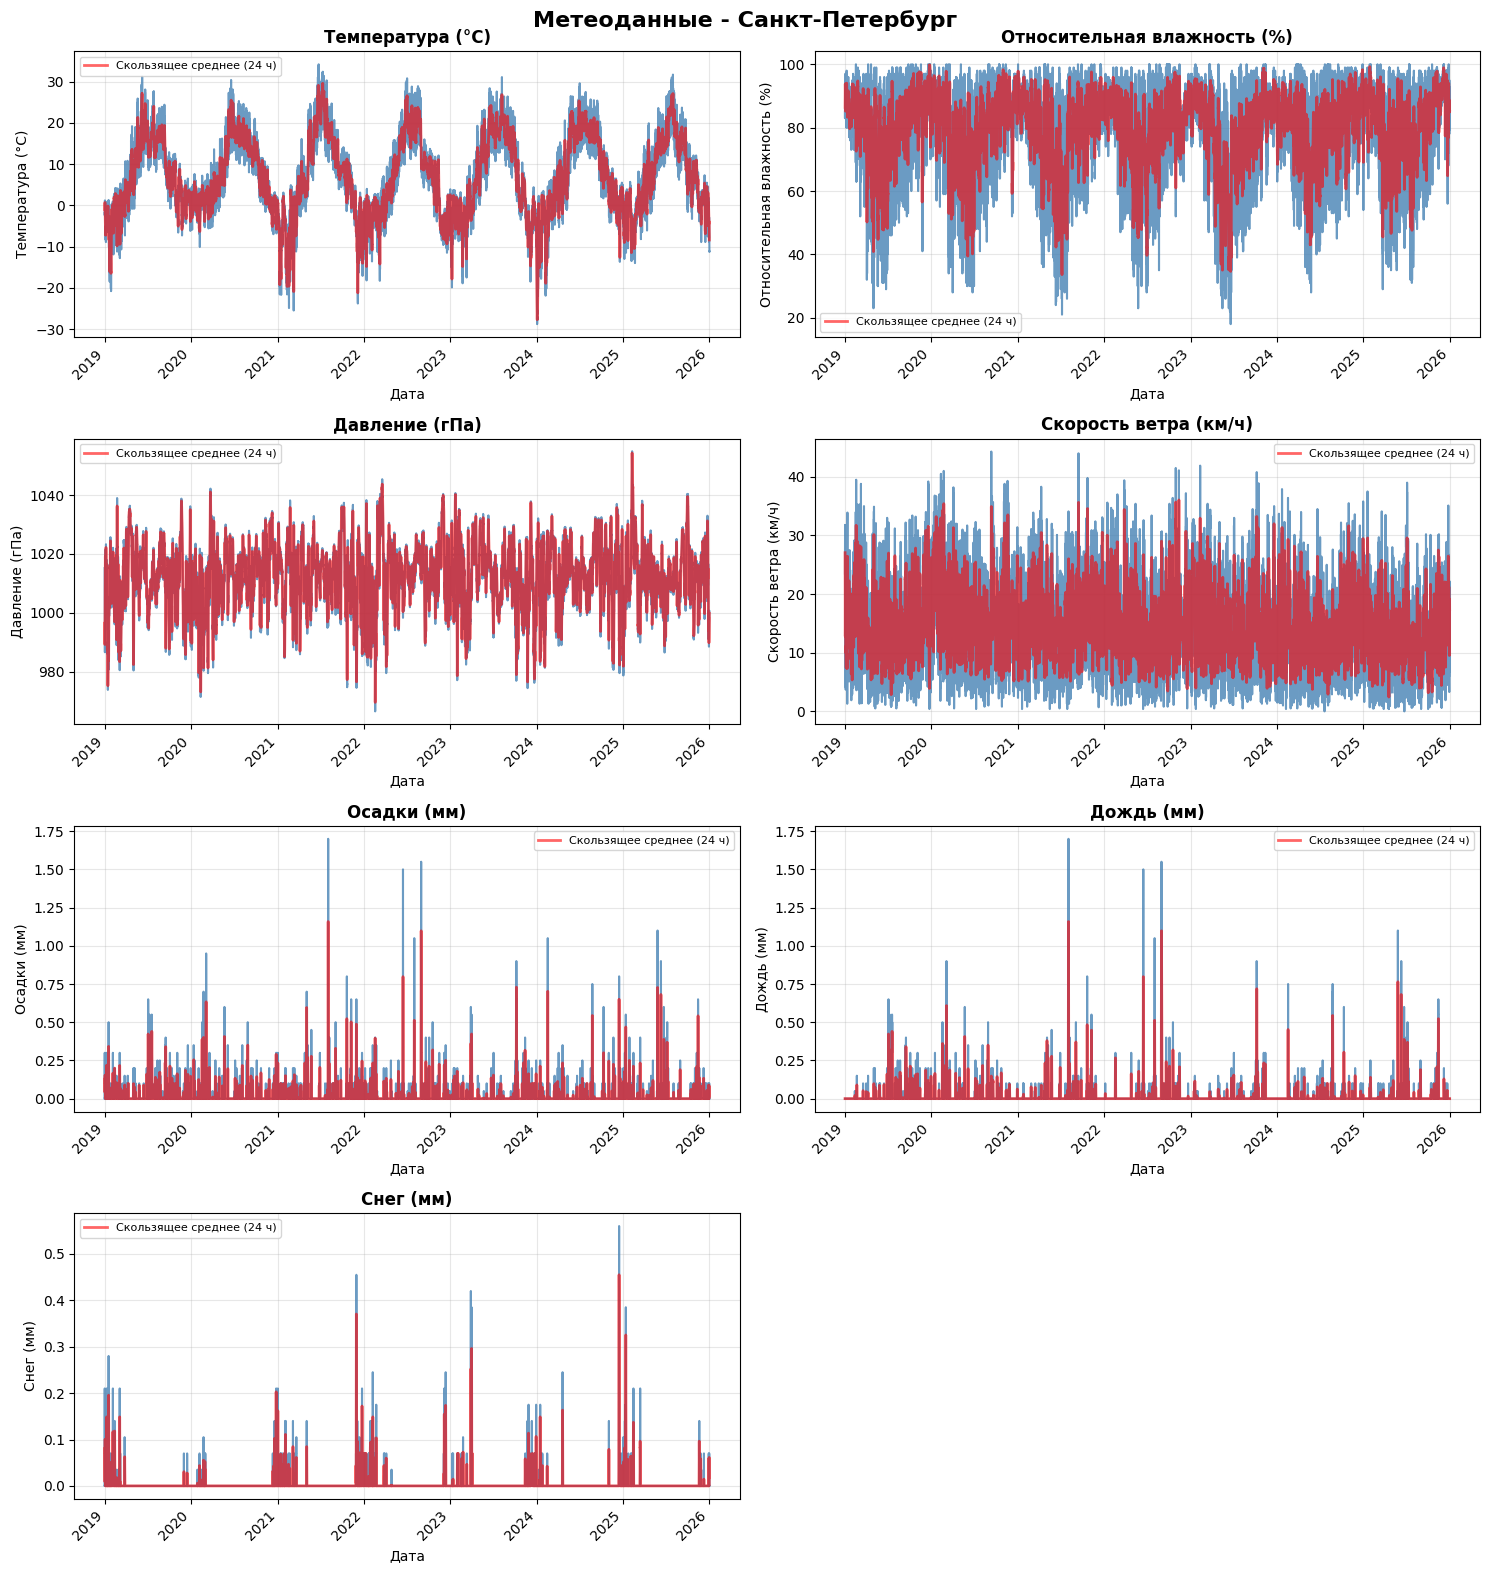


Сочи


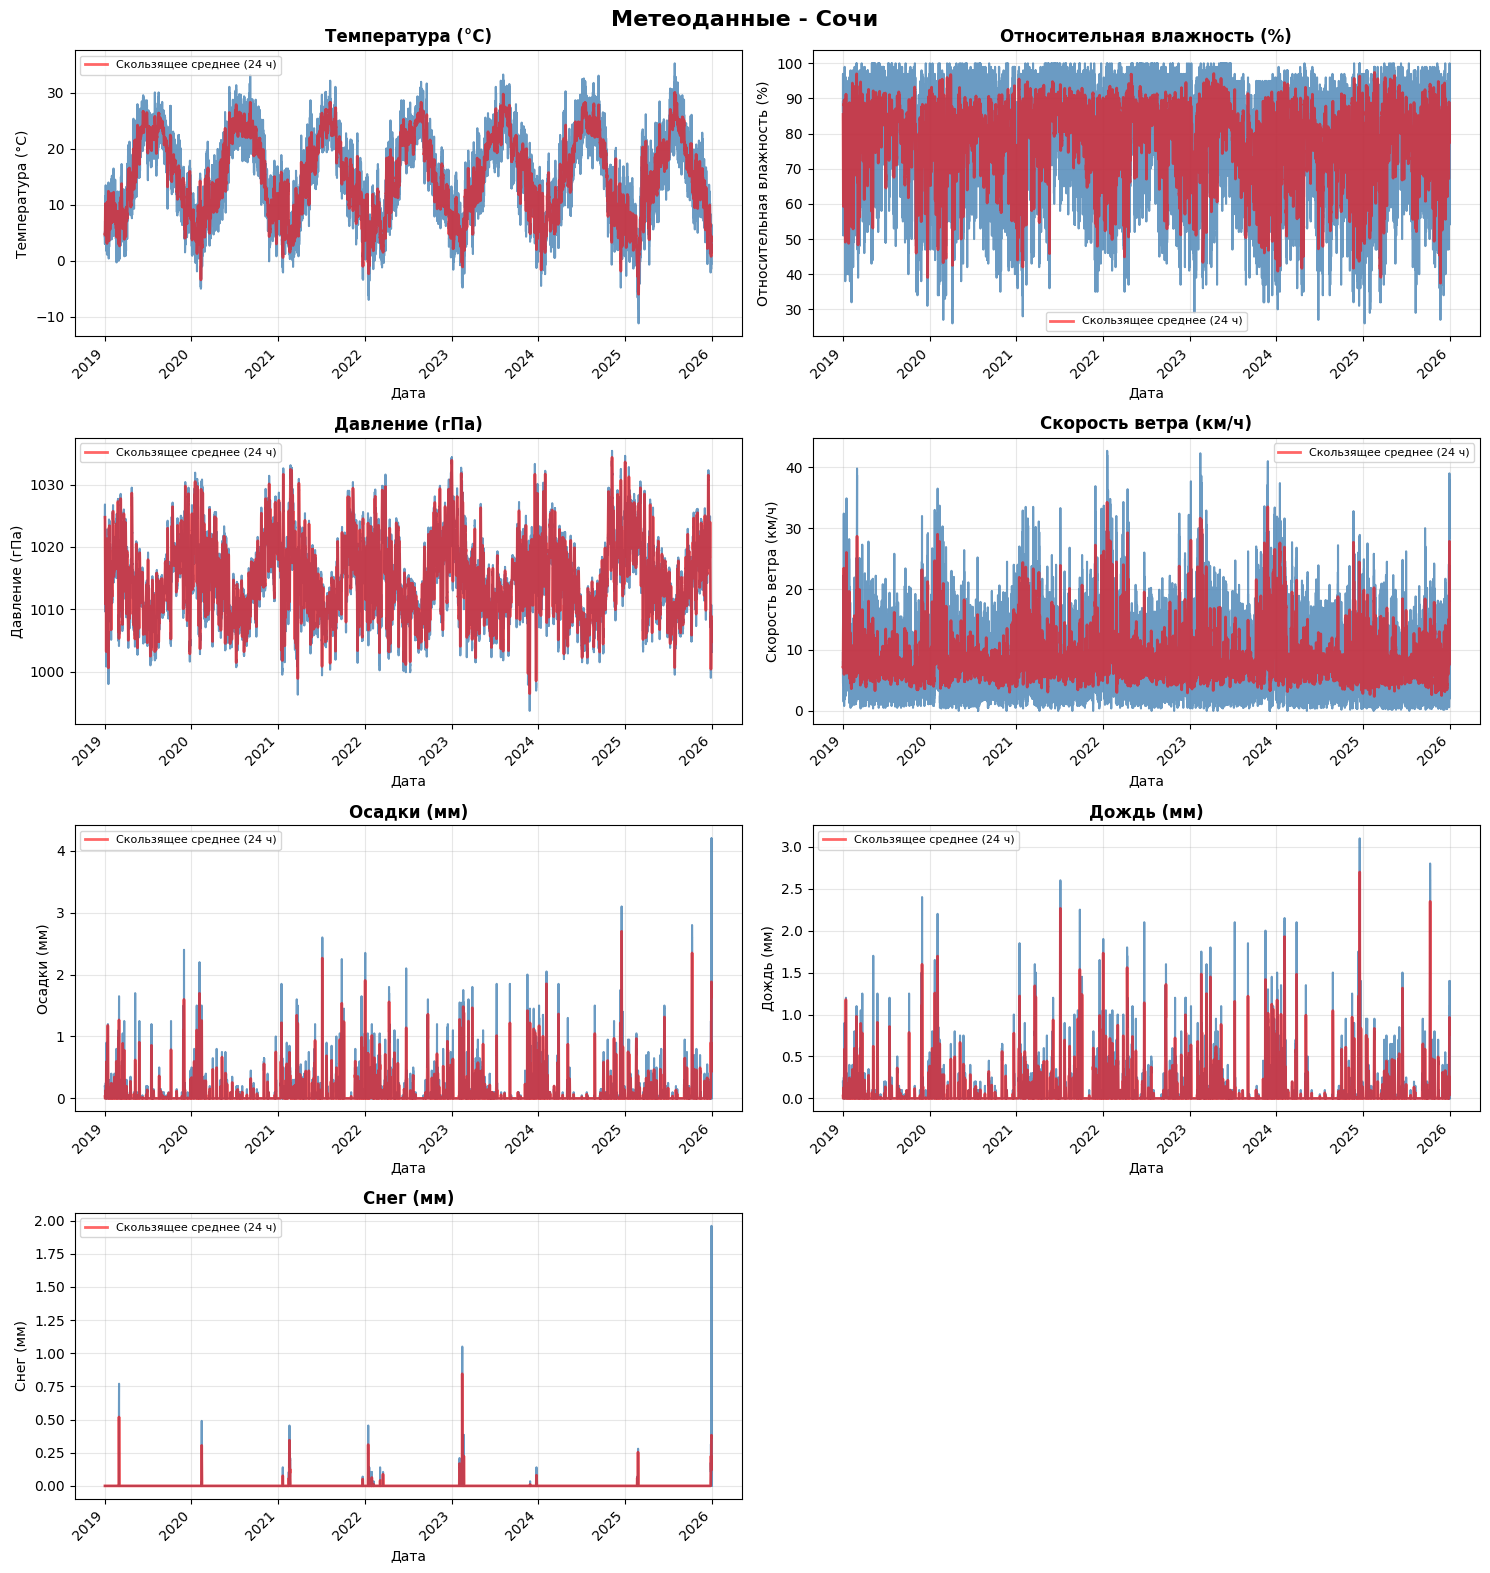

In [29]:
for city in cities:
    print(f"\n{city}")

    city_data = df[df['city'] == city].sort_values('ds')

    n_params = len(NUMERIC_COLS)
    n_cols = 2
    n_rows = (n_params + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    fig.suptitle(f'Метеоданные - {city}', fontsize=16, fontweight='bold')

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for idx, col in enumerate(NUMERIC_COLS):
        row = idx // n_cols
        col_idx = idx % n_cols

        ax = axes[row, col_idx]

        ax.plot(city_data['ds'], city_data[col],
               linewidth=1.5, alpha=0.8, color='steelblue')

        window = 24
        if len(city_data) > window:
            rolling_mean = city_data[col].rolling(window=window, center=True).mean()
            ax.plot(city_data['ds'], rolling_mean,
                   linewidth=2, color='red', alpha=0.6,
                   label=f'Скользящее среднее ({window} ч)')

        ax.set_title(rus_names.get(col, col), fontsize=12, fontweight='bold')
        ax.set_xlabel('Дата')
        ax.set_ylabel(rus_names.get(col, col))
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)

        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    for idx in range(len(NUMERIC_COLS), n_rows * n_cols):
        row = idx // n_cols
        col_idx = idx % n_cols
        fig.delaxes(axes[row, col_idx])

    plt.tight_layout()
    plt.show()

На графиках температуры и влажности можно заметить сезонность данных.

# Анализ Временного ряда

### Декомпозиция

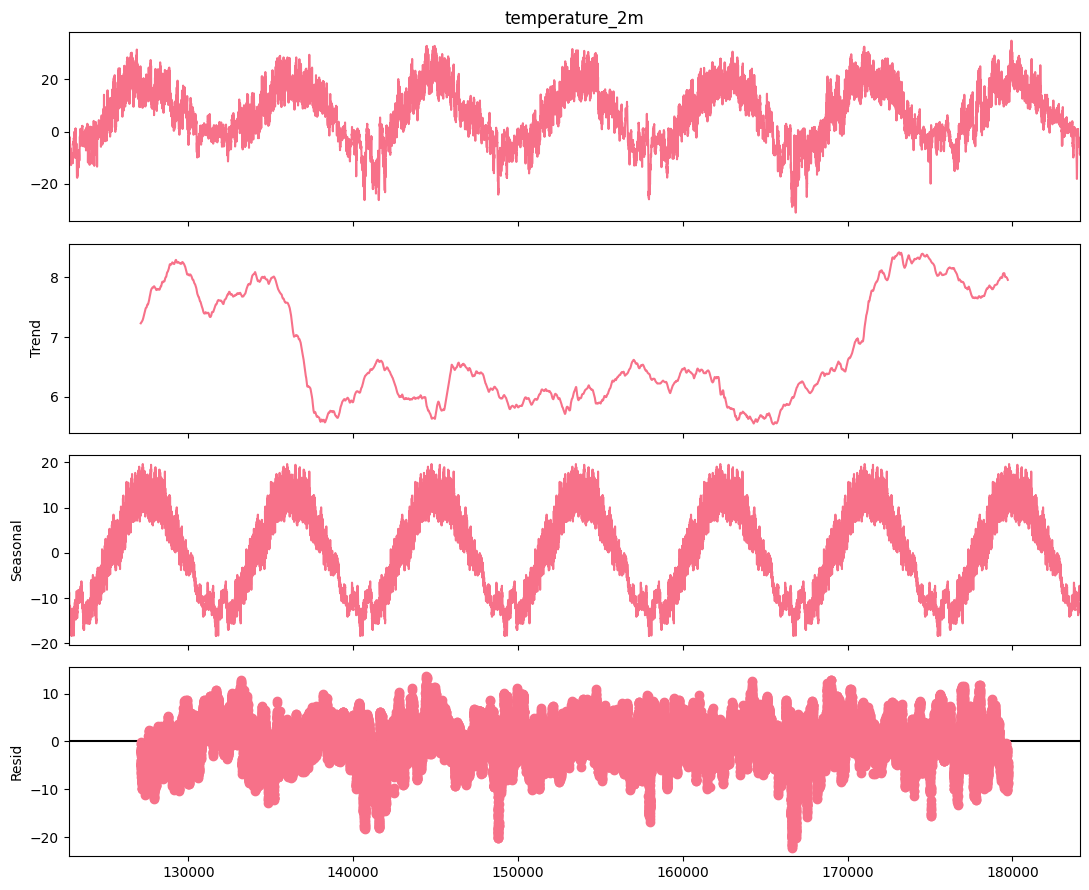

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

from pylab import rcParams
rcParams['figure.figsize'] = 11, 9
PERIOD = 24 * 365

city = "Москва"

city_df = (df[df['city'] == city].sort_values('ds'))

decompose = seasonal_decompose(
    city_df['temperature_2m'],
    period=PERIOD
)


decompose.plot()

plt.show()

По третьему графику видна сильная сезонность

Спектральный анализ

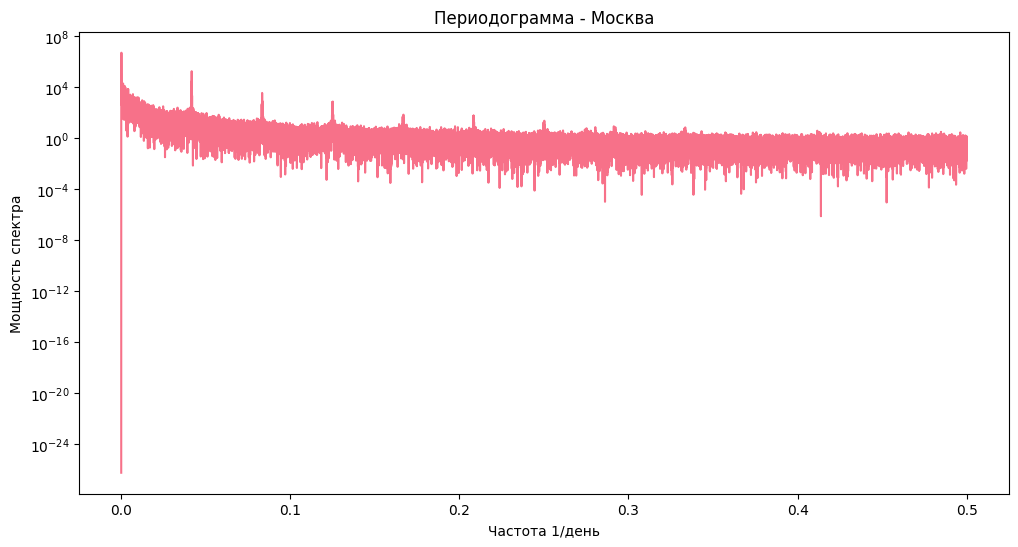

In [31]:
from scipy.signal import periodogram

city = "Москва"

city_df = (df[df['city'] == city].sort_values('ds'))


frequencies, spectrum = periodogram(city_df['temperature_2m'], fs=1.0)

plt.figure(figsize=(12, 6))
plt.semilogy(frequencies, spectrum)
plt.title('Периодограмма - Москва')
plt.xlabel('Частота 1/день')
plt.ylabel('Мощность спектра')
plt.show()

<Figure size 1000x300 with 0 Axes>

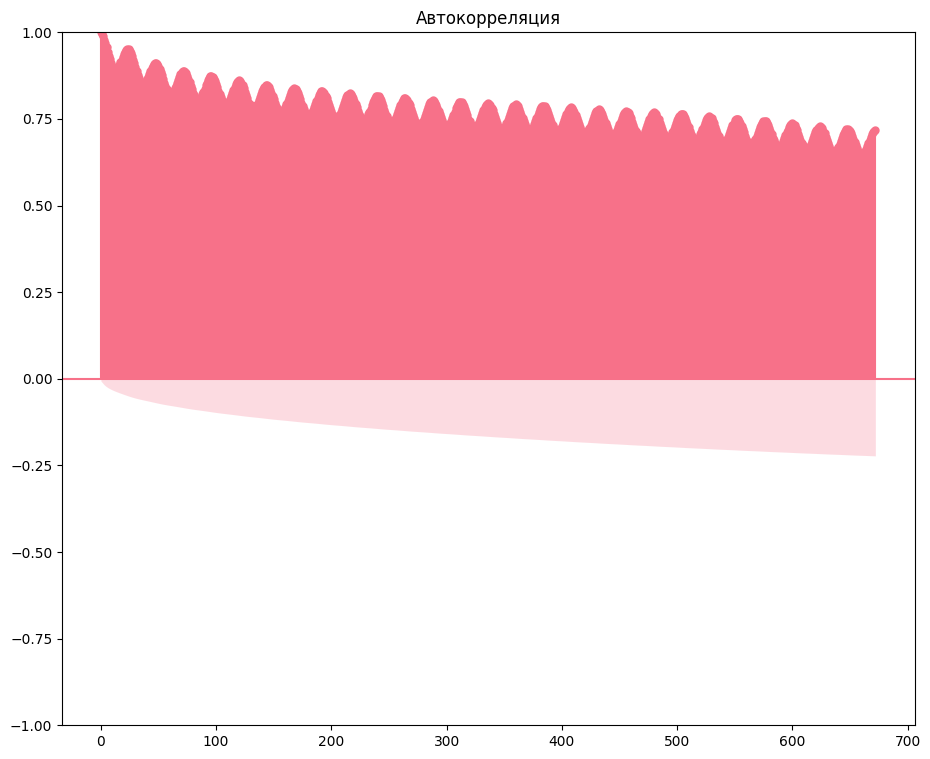

In [32]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

city = "Москва"

city_df = (df[df['city'] == city].sort_values('ds'))

data_acf = city_df['temperature_2m']

plt.figure(figsize=(10, 3))

plot_acf(data_acf, lags=24 * 7 * 4, title='Автокорреляция')

plt.show()

Нетрудно заметить волнообразне поведение графика - признак сезонности.
Даже при месячных(4 недели) лагах значения не опускаются ниже 0.70, что говорит о высокой зависимости.

Приведение к стационарному ряду


In [33]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(city_df['temperature_2m'])
print(f"p-value: {result[1]}")

# df['seasonal_diff'] = df.groupby('city')['temperature_2m'].transform(lambda x: x.diff(periods=365))

# print(df.isna().sum())

# plt.figure(figsize=(11, 8))
# plt.plot(df['seasonal_diff'], color='green', label='Seasonal Difference (365d)')
# plt.axhline(0, color='red', linestyle='--')
# plt.title("Ряд после сезонного дифференцирования (356d)")
# plt.legend()
# plt.show()

p-value: 3.087539316673135e-08


## Feature engineering

### Корреляционная матрица

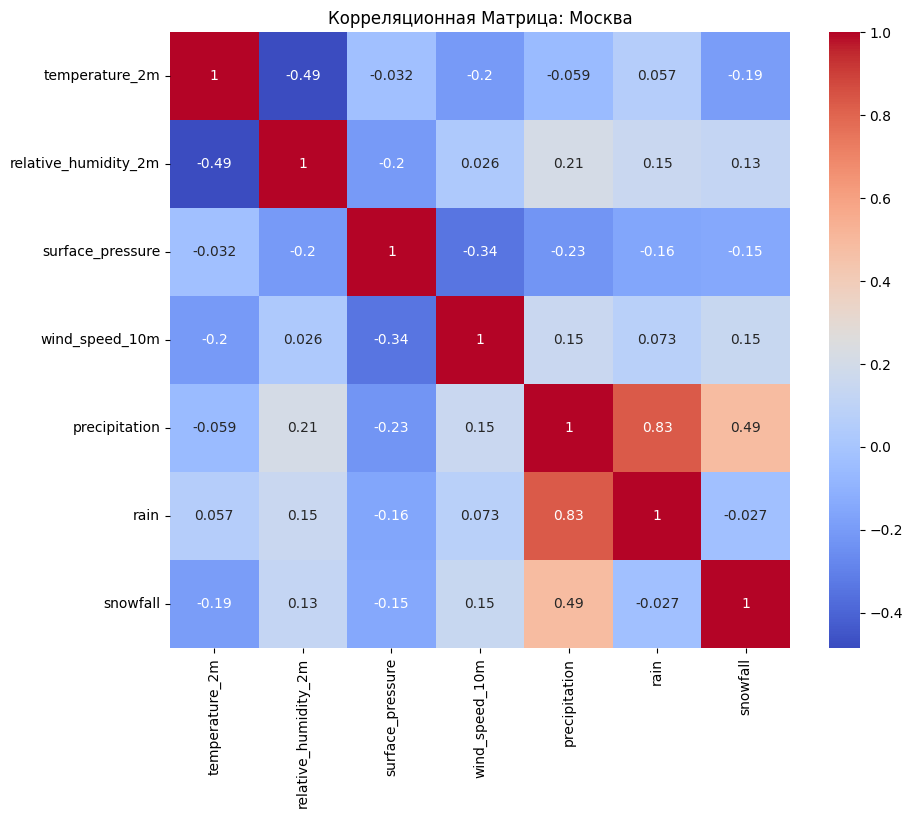

In [34]:
city = "Москва"

city_df = (df[df['city'] == city].sort_values('ds'))

plt.figure(figsize=(10, 8))

sns.heatmap(
    city_df[NUMERIC_COLS].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(f'Корреляционная Матрица: {city}')

plt.show()

По матрице хорошо видны коррелирющие признаки:

- Осадки -> Дождь и снег, т.к. дождь и снег составляют основную часть осадков в Москве
- Температура -> влажность и скорость ветра
- Атмосферное давление и осадки со скоростью ветра

## Рвзделение данных

In [35]:
df = df.sort_values(['city', 'ds'])

train_part_df = []
val_part_df = []
test_part_df = []

for city in df['city'].unique():
    city_df = df[df['city'] == city]

    train_df_size = int(len(city_df) * 0.7)
    val_df_size = int(len(city_df) * 0.15)

    train_part_df.append(
        city_df.iloc[:train_df_size]
    )

    val_part_df.append(
        city_df.iloc[train_df_size:train_df_size + val_df_size]
    )

    test_part_df.append(
        city_df.iloc[train_df_size + val_df_size:]
    )

train_df = pd.concat(train_part_df)
val_df = pd.concat(val_part_df)
test_df = pd.concat(test_part_df)

for dataframe in [train_df, val_df, test_df]:
    print(len(dataframe))
    print(dataframe['ds'].min())
    print(dataframe["ds"].max(), '\n')



257727
2019-01-01 00:00:00
2023-11-25 20:00:00 

55227
2023-11-25 06:00:00
2024-12-13 09:00:00 

55233
2024-12-12 16:00:00
2025-12-31 23:00:00 



 Данные были разделены в отношении 70/15/15

### Features

Установим таргет

In [36]:
forecast_horizon = 24 * 7

for dataframe in [train_df, val_df, test_df]:
    dataframe['target'] = dataframe.groupby('city')['temperature_2m'].shift(-forecast_horizon)

In [37]:
def create_features(df, lags=[1,2,3,7], windows=[7,14,30]):
    df = df.copy()
    df['hour'] = df['ds'].dt.hour
    df['dayofweek'] = df['ds'].dt.dayofweek
    df['month'] = df['ds'].dt.month

    for lag in lags:
        df[f'temp_lag_{lag}'] = df.groupby('city')['temperature_2m'].shift(lag)

    for win in windows:
        df[f'temp_roll_mean_{win}'] = df.groupby('city')['temperature_2m'].transform(
            lambda x: x.shift(1).rolling(win, min_periods=1).mean()
        )
        df[f'temp_roll_std_{win}'] = df.groupby('city')['temperature_2m'].transform(
            lambda x: x.shift(1).rolling(win, min_periods=1).std()
        )
    return df

train_df = create_features(train_df)
val_df = create_features(val_df)
test_df = create_features(test_df)

Цикличность

In [38]:
for dataframe in [train_df, val_df, test_df]:
    dataframe['hour_sin'] = np.sin(2 * np.pi * dataframe['hour'] / 24)
    dataframe['hour_cos'] = np.cos(2 * np.pi * dataframe['hour'] / 24)
    dataframe['month_sin'] = np.sin(2 * np.pi * dataframe['month'] / 12)
    dataframe['month_cos'] = np.cos(2 * np.pi * dataframe['month'] / 12)

In [39]:
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()

In [40]:
train_df.head()

,ds,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city,...,temp_roll_mean_7,temp_roll_std_7,temp_roll_mean_14,temp_roll_std_14,temp_roll_mean_30,temp_roll_std_30,hour_sin,hour_cos,month_sin,month_cos
7,2019-01-01 07:00:00,-13.9,61.0,0.0,0.0,0.0,0.0,15.1,1007.400024,Благовещенск,...,-12.642857,0.725390,-12.642857,0.725390,-12.642857,0.725390,0.965926,-0.258819,0.5,0.866025
8,2019-01-01 08:00:00,-14.5,62.0,0.0,0.0,0.0,0.0,15.1,1007.700012,Благовещенск,...,-12.671428,0.776132,-12.800000,0.805339,-12.800000,0.805339,0.866025,-0.500000,0.5,0.866025
9,2019-01-01 09:00:00,-14.0,61.0,0.0,0.0,0.0,0.0,15.3,1007.400024,Благовещенск,...,-12.857143,1.035788,-12.988889,0.942662,-12.988889,0.942662,0.707107,-0.707107,0.5,0.866025
10,2019-01-01 10:00:00,-13.4,61.0,0.0,0.0,0.0,1.0,14.9,1007.400024,Благовещенск,...,-13.071428,1.102594,-13.090000,0.944516,-13.090000,0.944516,0.500000,-0.866025,0.5,0.866025
11,2019-01-01 11:00:00,-12.3,59.0,0.0,0.0,0.0,1.0,14.0,1007.700012,Благовещенск,...,-13.257143,1.017935,-13.118182,0.900909,-13.118182,0.900909,0.258819,-0.965926,0.5,0.866025


Обучение моделей

In [49]:
models_train_df = pd.get_dummies(
    train_df,
    columns=['city'],
    drop_first=True
)

models_val_df = pd.get_dummies(
    val_df,
    columns=['city'],
    drop_first=True
)

models_test_df = pd.get_dummies(
    test_df,
    columns=['city'],
    drop_first=True
)

models_train_df = models_train_df.dropna()
models_val_df = models_val_df.dropna()
models_test_df = models_test_df.dropna()

In [50]:
drop_cols = [
    'ds',
    'target'
]

y_train = models_train_df['target']
X_train = models_train_df.drop(columns=drop_cols)

y_val = models_val_df['target']
X_val = models_val_df.drop(columns=drop_cols)

y_test = models_test_df['target']
X_test = models_test_df.drop(columns=drop_cols)

Случайный лес

In [51]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=30,
    random_state=42,
    max_depth=8,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

Градиент Буст

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_val)

Дерево

In [46]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_val)

### Метрики

In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred):
    y_true_diff = np.diff(y_true)
    y_pred_diff = np.diff(y_pred)

    correct_signs = np.sum((y_true_diff * y_pred_diff) > 0)
    total_changes = len(y_true_diff)

    return correct_signs / total_changes * 100

def directional_r2(y_true, y_pred):
    y_true_diff = np.diff(y_true)
    y_pred_diff = np.diff(y_pred)

    residuals = y_true_diff - y_pred_diff

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true_diff - np.mean(y_true_diff))**2)

    if ss_tot == 0:
        return np.nan

    return 1 - (ss_res / ss_tot)

In [53]:
def all_metrics(y_true, y_pred):
    metrics = {
        'MAE': mae(y_true, y_pred),
        'WAPE (%)': wape(y_true, y_pred),
        'MAPE (%)': mape(y_true, y_pred),
        'Directional Accuracy (%)': directional_accuracy(y_true, y_pred),
        'Directional R²': directional_r2(y_true, y_pred),
    }
    return metrics

test_metrics = {'gb': all_metrics(y_val.values, gb_pred),
                'rf': all_metrics(y_val.values, rf_pred),
                'dt': all_metrics(y_val.values, dt_pred)}

metrics_df = pd.DataFrame(test_metrics).T

metrics_df = metrics_df.round({
    'MAE': 3,
    'WAPE (%)': 2,
    'MAPE (%)': 2,
    'Directional Accuracy (%)': 1,
    'Directional R²': 3
})

print("\n Сравнение моделей:")
metrics_df


 Сравнение моделей:


,MAE,WAPE (%),MAPE (%),Directional Accuracy (%),Directional R²
gb,3.396,26.15,98.06,64.3,0.218
rf,3.531,27.19,96.54,43.4,-0.148
dt,4.553,35.07,125.93,34.9,-12.249


Как показывает Directional Accuracy, Gradient Boost является наилучшим способом в нашем случае, т.к. показывает 64%.

А Decision Tree оказалось наиболее часто ошибающимся, что происходит из-за шума.



## Сравнение рекурсивного рассчета и direct

### Рекурсия и прямой подход (подготовка)

In [61]:
rec_train_df = models_train_df.copy()
rec_val_df = models_val_df.copy()
rec_test_df = models_test_df.copy()

dir_train_df = models_train_df.copy()
dir_val_df = models_val_df.copy()
dir_test_df = models_test_df.copy()

for dataframe in [rec_train_df, rec_val_df, rec_test_df]:
    dataframe['rec_target'] = dataframe['temperature_2m'].shift(-1)

for dataframe in [dir_train_df, dir_val_df, dir_test_df]:
    dataframe['dir_target'] = dataframe['temperature_2m'].shift(-forecast_horizon)

dir_train_df = dir_train_df.dropna()
dir_val_df = dir_val_df.dropna()
dir_test_df = dir_test_df.dropna()

rec_train_df = rec_train_df.dropna()
rec_val_df = rec_val_df.dropna()
rec_test_df = rec_test_df.dropna()

rec_y_train = rec_train_df['rec_target']
rec_X_train = rec_train_df.drop(columns=['ds', 'target', 'rec_target'])

rec_y_val = rec_val_df['rec_target']
rec_X_val = rec_val_df.drop(columns=['ds', 'target', 'rec_target'])

dir_y_train = dir_train_df['dir_target']
dir_X_train = dir_train_df.drop(columns=['ds', 'target', 'dir_target'])

dir_y_val = dir_val_df['dir_target']
dir_X_val = dir_val_df.drop(columns=['ds', 'target', 'dir_target'])


In [57]:
dir_real = dir_y_val.iloc[:200].values
rec_real = rec_y_val.iloc[:200].values

In [63]:
from sklearn.ensemble import GradientBoostingRegressor


rec_gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
rec_gb_model.fit(rec_X_train[:400], rec_y_train[:400])

dir_gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
dir_gb_model.fit(dir_X_train[:400], dir_y_train[:400])

GradientBoostingRegressor(random_state=42)

In [64]:
def rec_lag_forecast(features, new_value):
    features = features.copy()
    for lag in range(24, 0, -1):
        lag_col = f'temp_lag_{lag}'
        if lag_col in features:
            if lag == 1:
                features[lag_col] = new_value
            else:
                prev_lag_col = f'temp_lag_{lag - 1}'
                if prev_lag_col in features:
                    features[lag_col] = features[prev_lag_col]

    if 'temp_roll_mean_24' in features:
        lag_values = [features.get(f'temp_lag_{i}') for i in range(1, 25)]
        if any(v is not None for v in lag_values):
            features['temp_roll_mean_24'] = np.nanmean(lag_values)

    return features

In [69]:
dir_y_pred = dir_gb_model.predict(dir_X_val[:200])

reccut = 200

rec_predictions = []
sample = rec_X_val.iloc[:reccut].copy()

for i in range(len(sample)):
    current_row = sample.iloc[i].copy()

    for step in range(24 * 7):
        row = pd.DataFrame([current_row])
        prediction = rec_gb_model.predict(row)[0]
        if step < 24 * 7 - 1:
            current_row = rec_lag_forecast(current_row, prediction)

    rec_predictions.append(prediction)

rec_y_pred = np.array(rec_predictions)

Метрики для рекурсии и прямого похода:

In [70]:
metrics = {'recursion': all_metrics(rec_real, rec_y_pred),
           'direct': all_metrics(dir_real, dir_y_pred)}

metrics_df = pd.DataFrame(metrics).T

metrics_df = metrics_df.round({
    'MAE': 3,
    'WAPE (%)': 2,
    'MAPE (%)': 2,
    'Directional Accuracy (%)': 1,
    'Directional R²': 3
})

print("\n Сравнение моделей:")
metrics_df



 Сравнение моделей:


,MAE,WAPE (%),MAPE (%),Directional Accuracy (%),Directional R²
recursion,1.612,11.23,15.57,60.8,0.168
direct,6.948,47.34,94.36,57.3,-1.118


Рекурсивный прогноз показывает лучшую статистику по сравнению с прямым. Это объясняется тем, что рекурсивный подход использует авторегрессионную структуру ряда — каждый следующий прогноз опирается на предыдущие предсказания, что позволяет точно продолжать локальный тренд.

Однако рекурсивная модель показала низкий Directional R², что указывает на плохое предсказание направления движения температуры — ошибки накапливаются, и прогноз постепенно уползает к среднему. Прямая модель в этом компоненте оказалась вообще отрицательной, но её Directional Accuracy почти сравнялась с рекурсивной, что говорит о незначительном преимуществе последней.

Из-за лучшего Directional predict было решено использовать рекурсивный метод.

## Optuna

In [80]:
import optuna

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [86]:
cut = 1000

In [88]:
if isinstance(rec_X_train, pd.DataFrame):
    print(f"  rec_X_train: {rec_X_train.shape}")
    print(f"  rec_y_train: {len(rec_y_train)}")
    print(f"  rec_X_val: {rec_X_val.shape}")
    print(f"  rec_y_val: {len(rec_y_val)}")

exclude_cols = ['ds', 'city', 'target', 'dir_target']
feature_cols = [col for col in rec_X_train.columns if col not in exclude_cols]

X_train = rec_X_train[feature_cols]
X_val = rec_X_val[feature_cols]
y_train = rec_y_train.values
y_val = rec_y_val.values

  rec_X_train: (256676, 30)
  rec_y_train: 256676
  rec_X_val: (54176, 30)
  rec_y_val: 54176


In [89]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 50, step=5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20, step=2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0, step=0.1),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0, step=0.1),
        'alpha': trial.suggest_float('alpha', 0.1, 0.9, step=0.1)
    }

    model = GradientBoostingRegressor(
        **params,
        random_state=42,
        verbose=0
    )

    model.fit(X_train[:cut], y_train[:cut])
    y_pred = model.predict(X_val[:cut])

    mae = mean_absolute_error(y_val[:cut], y_pred)

    trial.set_user_attr('rmse', np.sqrt(mean_squared_error(y_val[:cut], y_pred[:cut])))
    trial.set_user_attr('r2', r2_score(y_val[:cut], y_pred))

    return mae

In [90]:
study = optuna.create_study(
    direction='minimize',
    study_name='recursive_gb_optimization'
)

study.optimize(objective, n_trials=10, show_progress_bar=True)

[I 2026-05-25 19:51:02,774] A new study created in memory with name: recursive_gb_optimization


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-05-25 19:51:03,833] Trial 0 finished with value: 0.9307990935062453 and parameters: {'n_estimators': 250, 'learning_rate': 0.0663758277889693, 'max_depth': 4, 'min_samples_split': 25, 'min_samples_leaf': 20, 'subsample': 0.6, 'max_features': 0.7, 'alpha': 0.2}. Best is trial 0 with value: 0.9307990935062453.
[I 2026-05-25 19:51:05,344] Trial 1 finished with value: 0.8445758188212249 and parameters: {'n_estimators': 200, 'learning_rate': 0.03420507177780987, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'subsample': 0.6, 'max_features': 0.9, 'alpha': 0.5}. Best is trial 1 with value: 0.8445758188212249.
[I 2026-05-25 19:51:06,188] Trial 2 finished with value: 0.8933432324809685 and parameters: {'n_estimators': 150, 'learning_rate': 0.17578317930489523, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 14, 'subsample': 0.7, 'max_features': 0.9, 'alpha': 0.7000000000000001}. Best is trial 1 with value: 0.8445758188212249.
[I 2026-05-25 19:51:07,705] Tri

In [92]:
best_params = study.best_params
for key, value in best_params.items():
    print(f"  {key:20s}: {value}")

print(f"\n Лучший MAE на валидации: {study.best_value:.4f}")

  n_estimators        : 200
  learning_rate       : 0.03420507177780987
  max_depth           : 7
  min_samples_split   : 5
  min_samples_leaf    : 10
  subsample           : 0.6
  max_features        : 0.9
  alpha               : 0.5

📊 Лучший MAE на валидации: 0.8446


## Финальная Модель

In [100]:
final_params = {
    **best_params,
    'random_state': 42,
    'verbose': 1
}

rec_y_test = rec_test_df['rec_target']
rec_X_test = rec_test_df.drop(columns=['ds', 'target', 'rec_target'])

print("\nПараметры финальной модели:")
for key, value in final_params.items():
    print(f"  {key:20s}: {value}")

final_model = GradientBoostingRegressor(**final_params)
final_model.fit(X_train[:5000], y_train[:5000])

y_test_pred = final_model.predict(rec_X_test)


Параметры финальной модели:
  n_estimators        : 200
  learning_rate       : 0.03420507177780987
  max_depth           : 7
  min_samples_split   : 5
  min_samples_leaf    : 10
  subsample           : 0.6
  max_features        : 0.9
  alpha               : 0.5
  random_state        : 42
  verbose             : 1
      Iter       Train Loss      OOB Improve   Remaining Time 
         1         222.2843          15.7391            9.76s
         2         210.3570          19.1260            9.81s
         3         192.9007           8.3781            9.71s
         4         179.8108          12.5830            9.60s
         5         168.1493          12.5599            9.64s
         6         156.2491          10.2424            9.62s
         7         145.2039           9.5440            9.73s
         8         138.5773          14.4747            9.70s
         9         127.0709           5.5147           10.06s
        10         117.4837           6.8305            9.90s


In [101]:
metrics = {'recursion': all_metrics(rec_y_test, y_test_pred)}

metrics_df = pd.DataFrame(metrics).T

metrics_df = metrics_df.round({
    'MAE': 3,
    'WAPE (%)': 2,
    'MAPE (%)': 2,
    'Directional Accuracy (%)': 1,
    'Directional R²': 3
})

print("\n Сравнение моделей:")
metrics_df


 Сравнение моделей:


,MAE,WAPE (%),MAPE (%),Directional Accuracy (%),Directional R²
recursion,0.662,5.41,21.54,70.0,-0.104


Качество заметно улучшилось

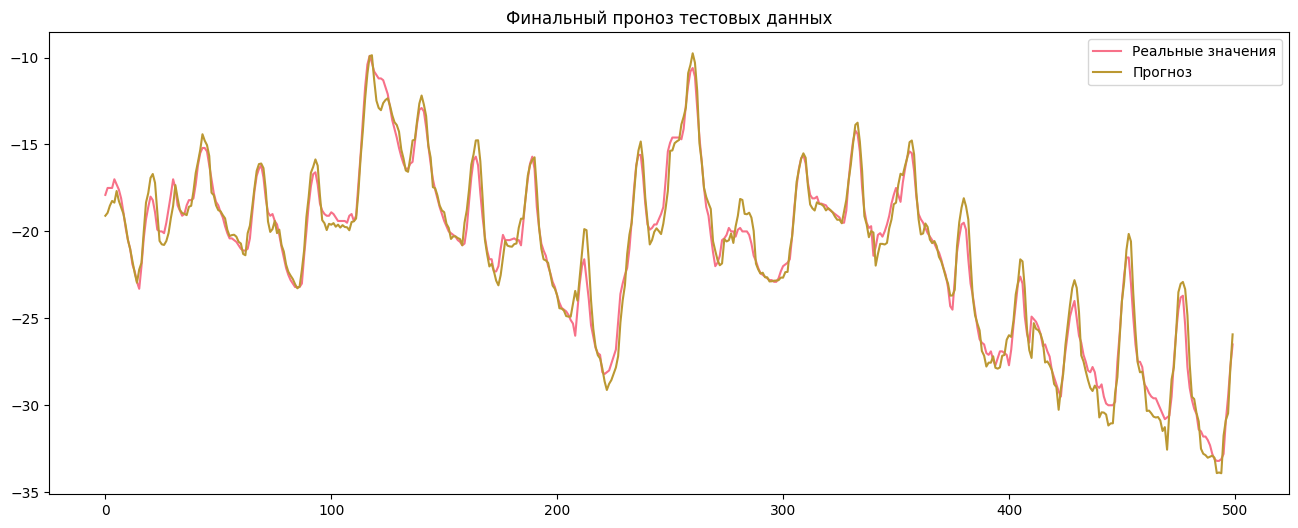

In [102]:
plt.figure(figsize=(16, 6))

plt.plot(
    rec_y_test.values[:500],
    label='Реальные значения'
)

plt.plot(
    y_test_pred[:500],
    label='Прогноз'
)

plt.legend()

plt.title('Финальный проноз тестовых данных')

plt.show()

Как можно заметить модель довольно-таки хорошо предсказывает данные.

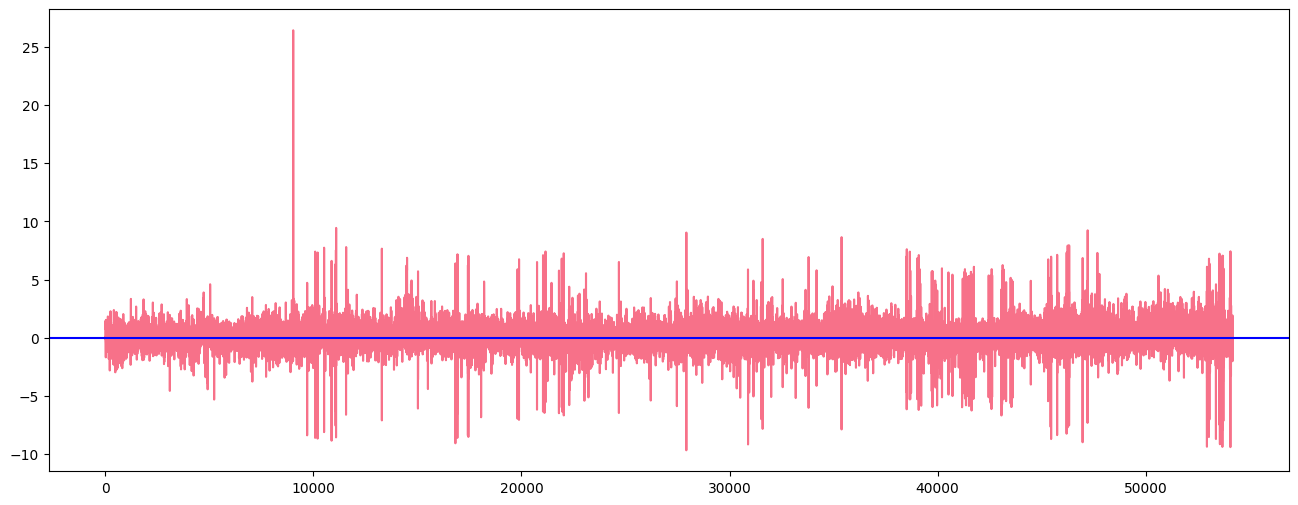

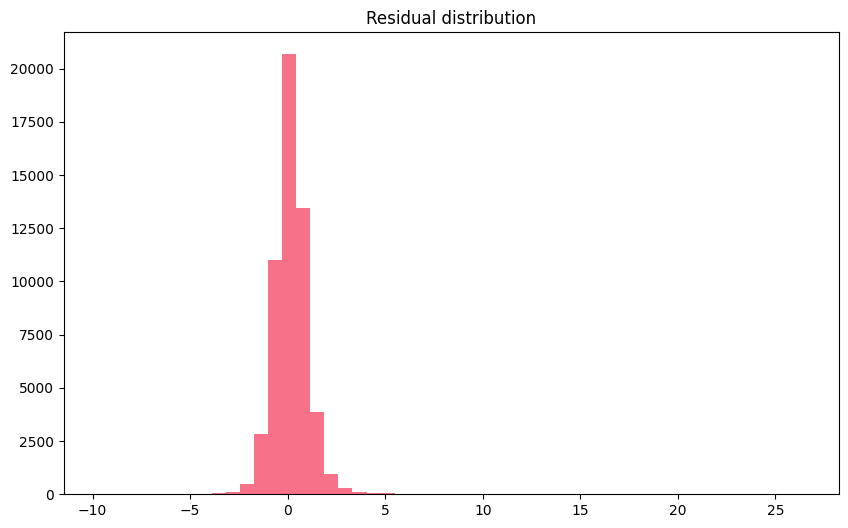

In [111]:
residuals = rec_y_test.values - y_test_pred

plt.figure(figsize=(16, 6))

plt.plot(residuals)

plt.axhline(0, color='blue')

plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=50
)

plt.title('Residual distribution')

plt.show()

## Заключение


Благодаря использованию Градиентного бустинга с рекурсивным методом, которые показали себя лучше по метрикам, модель может предсказывать погоду с вероятностью 60%.

Оптимизация с помощью Optuna повысила эффективность модели почти на 10%

В ходе данной лабораторной работы были проведены:

- Обработка и исправление поломанного xslx файла
- ОБработка и достроение данных
- Пострение Дерева Решений, Градиентного Бустинга и случайного леса
- Анализ работы прямого и рекурсивного метода
- оптимизация параметров через Optuna

Был проделан анализ времменных рядов.